Using input data from /work/mh1126/m300950/rain-evap-nils/sdm-eurec4a/data/model/input_v4.2
Using data from /work/mh1126/m300950/rain-evap-nils/sdm-eurec4a-CLEO/data/output_v4.2
data_dir_novent: /work/mh1126/m300950/rain-evap-nils/sdm-eurec4a-CLEO/data/output_v4.2_novent
data_dir_novent: /work/mh1126/m300950/rain-evap-nils/sdm-eurec4a-CLEO/data/output_v4.2_novent


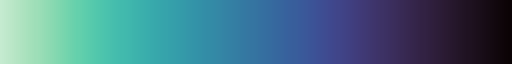

In [1]:
from pathlib import Path
import textwrap
from tqdm import tqdm

from ruamel.yaml import YAML

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as patches
import matplotlib.collections as mcollections
import matplotlib.patches as mpatches

import xarray as xr
from typing import Tuple, Literal, Union

import seaborn as sns

from sdm_eurec4a.visulization import (
    set_paper_rcParams,
    adjust_lightness_array,
    adjust_lightness,
    label_from_attrs,
    add_additional_axis,
    add_subplotlabel,
    save_figure,
)
from sdm_eurec4a import RepositoryPath
from sdm_eurec4a import data_loading
from sdm_eurec4a.constants import TimeSlices
from sdm_eurec4a import conversions
from sdm_eurec4a.input_processing import models as smodels
from sdm_eurec4a.identifications import match_clouds_and_cloudcomposite, match_clouds_and_dropsondes
from sdm_eurec4a.constants import TimeSlices
from sdm_eurec4a.visulization import (
    set_custom_rcParams,
    set_paper_rcParams,
    label_from_attrs,
    adjust_lightness_array,
    plot_one_one,
    handler_map_alpha,
    save_figure,
    add_subplotlabel,
)
from sdm_eurec4a import RepositoryPath
from sdm_eurec4a import data_loading
from sdm_eurec4a.reductions import mean_and_stderror_of_mean
from sdm_eurec4a.conversions import (
    msd_from_psd_dataarray,
    potential_temperature_from_temperature_pressure,
    relative_humidity_from_tps,
    temperature_from_potential_temperature_pressure,
)
from sdm_eurec4a.input_processing import models as smodels
from sdm_eurec4a.identifications import match_clouds_and_cloudcomposite, match_clouds_and_dropsondes
from sdm_eurec4a.constants import TimeSlices


from sdm_eurec4a.reductions import mean_and_stderror_of_mean


default_colors = set_paper_rcParams()
# make sure that figures are not cut off
# pltrcParams.update({'figure.autolayout': True})

default_dark_colors = adjust_lightness_array(default_colors, 0.75)

RepoPaths = RepositoryPath("levante_m300950")

OBS_data_dir = RepoPaths.data_dir
input_data_dir = OBS_data_dir / Path("model/input_v4.2")

# data_dir = RepoPaths.CLEO_data_dir / Path("output_v4.4-CLEO_v0.39.7-input_v4.2")
# data_dir_v43 = RepoPaths.CLEO_data_dir / Path("output_v4.3-CLEO_v0.39.7-input_v4.2")
data_dir = RepoPaths.CLEO_data_dir / Path("output_v4.2")
data_dir_novent = Path("/work/mh1126/m300950/rain-evap-nils/sdm-eurec4a-CLEO/data/output_v4.2_novent/")
# data_dir_v41 = RepoPaths.CLEO_data_dir / Path("output_v4.1")
# data_dir_v40 = RepoPaths.CLEO_data_dir / Path("output_v4.0")

fig_dir = RepoPaths.fig_dir / Path("paper-review-version") / "updated-cleo"
fig_dir.mkdir(exist_ok=True, parents=False)
appendix_fig_dir = fig_dir / "appendix"
appendix_fig_dir.mkdir(exist_ok=True, parents=False)

print(f"Using input data from {input_data_dir}")
print(f"Using data from {data_dir}")
print(f"data_dir_novent: {data_dir_novent}")
print(f"data_dir_novent: {data_dir_novent}")

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=256):
    """https://stackoverflow.com/a/18926541/16372843"""
    new_cmap = mcolors.LinearSegmentedColormap.from_list(
        "trunc({n},{a:.2f},{b:.2f})".format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)),
    )
    return new_cmap


# strength_cmap = sns.cubehelix_palette(start=0.5, rot=-0.5, as_cmap=True)
full_strength_cmap = sns.color_palette("mako_r", as_cmap=True)
strength_cmap = truncate_colormap(full_strength_cmap, 0.05, 1)
strength_cmap

In [2]:
small_fig_size = np.array((16 / 3, 9 / 3))
square_fig_size = small_fig_size[0], small_fig_size[0]
large_figure_multiplicator = 12 / 8.3
large_fig_size = small_fig_size * large_figure_multiplicator
large_square_fig_size = large_fig_size[0], large_fig_size[0]
wide_fig_size = large_fig_size[0], small_fig_size[1]

# Data prepocessing

In [3]:
ds_eulerian = xr.open_dataset(
    data_loading.__eulerian_data_path__(data_dir=data_dir, microphysic="coalbure_condensation_small")
)
ds_eulerian = ds_eulerian.sel(time=TimeSlices.full_state)
ds_eulerian = data_loading.__post_process_eulerian_dataset__(ds=ds_eulerian)

ds_conservation = xr.open_dataset(
    data_loading.__conservation_data_path__(data_dir=data_dir, microphysic="coalbure_condensation_small")
)
ds_conservation = ds_conservation.sel(time=TimeSlices.full_state)
ds_conservation = data_loading.__post_process_conservation_dataset__(
    ds=ds_conservation,
    da_surface_area=ds_eulerian["surface_area"].mean("gridbox"),
    timestep=ds_conservation["time"].diff("time").mean().values,
)

In [4]:
microphysics_styles = data_loading.MicrophysicsStyles()
tuple(microphysics_styles)

('condensation',
 'collision_condensation',
 'coalbure_condensation_small',
 'coalbure_condensation_large')

In [5]:
def propagate_mean_sem(data, data_std, dim: str):

    N = len(data[dim])

    # Inter-model spread (std of model means)
    inter_model_spread = data.std(dim=dim, ddof=1) / N**0.5

    # Individual model uncertainty propagation
    individual_model_error = (data_std**2).sum(dim) ** 0.5 / N

    # Total propagated SEM
    total_sem = (inter_model_spread**2 + individual_model_error**2) ** 0.5

    return total_sem


def propagate_mean_std(data, data_std, dim: str):

    N = len(data[dim])

    # Inter-model spread (std of model means)
    inter_model_spread = data.std(dim=dim, ddof=1)

    # Individual model uncertainty propagation
    individual_model_error = (data_std**2).sum(dim) ** 0.5 / N

    # Total propagated SEM
    total_sem = (inter_model_spread**2 + individual_model_error**2) ** 0.5

    return total_sem

In [6]:
def scatter_and_errorbar(
    ax: plt.Axes,
    x_var: str,
    y_var: str,
    ds: xr.Dataset,
    ds_sem: xr.Dataset,
    microphysics: Literal[
        "null_microphysics",
        "condensation",
        "collision_condensation",
        "coalbure_condensation_small",
        "coalbure_condensation_large",
    ] = "condensation",
    x_multiply: float = 1.0,
    y_multiply: float = 1.0,
    plot_patch: bool = True,
    plot_annotations: bool = True,
    patch_width: float = 1,
    scatter_kwargs: Union[dict, None] = None,
    error_kwargs: dict = dict(fmt="", label="mean ± SEM", color="black", capsize=5, linewidth=2),
    annotation_kwargs: dict = dict(
        fontsize=12,
        color="black",
    ),
) -> Tuple[dict, dict]:

    x_attrs = ds[x_var].attrs.copy()
    x = x_multiply * ds[x_var].sel(microphysics=microphysics)
    x_sem = x_multiply * ds_sem[x_var].sel(microphysics=microphysics)
    # x_sem = x * 0
    x_mean = x.mean("cloud_id")
    x_std = propagate_mean_std(x, x_sem, dim="cloud_id")

    y_attrs = ds[y_var].attrs.copy()
    y = y_multiply * ds[y_var].sel(microphysics=microphysics)
    y_sem = y_multiply * ds_sem[y_var].sel(microphysics=microphysics)
    y_mean = y.mean("cloud_id")
    y_std = propagate_mean_std(y, y_sem, dim="cloud_id")

    if scatter_kwargs == None:
        scatter_kwargs = microphysics_styles.get_style(key=microphysics)
    else:
        pass

    pathcollection = ax.scatter(x, y, **scatter_kwargs)

    error_container = ax.errorbar(
        x=x_mean,
        y=y_mean,
        xerr=x_std,
        yerr=y_std,
        **error_kwargs,
    )

    # for (x, y), label in zip(
    #     (, (x_mean, y_mean + 4 * y_std)),
    #     (fr"{x_mean.data:.2f}$\pm${x_std.data:.2f}", fr"{y_mean.data:.2f}$\pm${y_std.data:.2f}"),
    # ) :

    increase = max(patch_width, 1)
    offset = 1.1  # offset by 10 % to the right and top

    x_xy = ((x_mean.data + x_std.data), y_mean.data)
    x_xytext = (offset * (x_mean.data + increase * x_std.data), y_mean.data)
    x_xy = (0, 0)
    x_xytext = (0, 0)

    x_label = rf"{x_mean.data:.2f} $\pm$ {x_std.data:.2f} ${x_attrs['units']}$"

    y_xy = (x_mean.data, (y_mean.data + y_std.data))
    y_xytext = (x_mean.data, offset * (y_mean.data + increase * y_std.data))
    y_xy = (0, 0)
    y_xytext = (0, 0)

    y_label = rf"{y_mean.data:.2f} $\pm$ {y_std.data:.2f} ${y_attrs['units']}$"

    print(x_label, y_label)

    if plot_annotations:

        x_annotation = ax.annotate(
            x_label,
            xy=x_xy,
            xytext=x_xytext,
            ha="left",
            va="center",
            **annotation_kwargs,
        )

        y_annotation = ax.annotate(
            y_label,
            xy=y_xy,
            xytext=y_xytext,
            ha="center",
            va="bottom",
            rotation=90,
            **annotation_kwargs,
        )
    else:
        y_annotation = None
        x_annotation = None

    # Create a Rectangle patch

    if plot_patch:
        if patch_width > 1.0:
            wide_error_kwargs = error_kwargs.copy()
            wide_error_kwargs.update(alpha=0.1)
            error_container_wide = ax.errorbar(
                x=x_mean,
                y=y_mean,
                xerr=patch_width * x_std,
                yerr=patch_width * y_std,
                **wide_error_kwargs,
            )

        xy = x_mean.data - patch_width * x_std.data, y_mean.data - patch_width * y_std.data
        dx = patch_width * 2 * x_std.data
        dy = patch_width * 2 * y_std.data

        rect = patches.Rectangle(xy, dx, dy, linewidth=1, edgecolor="None", facecolor="k", alpha=0.1)

        ax.add_patch(rect)
    else:
        rect = None

    return (
        dict(
            x_mean=x_mean,
            y_mean=y_mean,
            x_std=x_std,
            y_std=y_std,
            x_label=x_label,
            y_label=y_label,
        ),
        dict(
            pathcollection=pathcollection,
            error_container=error_container,
            rect=rect,
            y_annotation=y_annotation,
            x_annotation=x_annotation,
        ),
    )

### Load the cleo output data

- Data in physical gridbox coordinates
- Data normalized by cloud base height.
- Data without ventilation coefficient

In [7]:
cleo_dataset = data_loading.CleoDataset(
    data_dir=data_dir,
    microphysics=tuple(microphysics_styles),
)
# get physicsal height cleo output data
ds, ds_sem = cleo_dataset()
cleo_dataset.normalize_gridboxes()
# get normalized height cleo output data
ds_normalized, ds_normalized_sem = cleo_dataset()


# get non ventilated cleo output data
cleo_dataset_no_ventilation = data_loading.CleoDataset(
    data_dir=data_dir_novent,
    microphysics=('condensation',),
)
ds_no_ventilation, ds_sem_no_ventilation = cleo_dataset_no_ventilation()
# cleo_dataset.normalize_gridboxes()
# ds_normalized, ds_normalized_sem = cleo_dataset()

# valid_cleo_monitor_dataset = data_loading.CleoDataset(
#     data_dir= data_dir_v40,
#     microphysics=tuple(microphysics_styles),
# )
# # get physicsal height cleo output data
# ds_valid_cleo_monitor, ds_valid_cleo_monitor_sem = valid_cleo_monitor_dataset()

condensation


/home/m/m300950/mamba/envs/sdm_eurec4a_env312/lib/python3.12/site-packages/sdm_eurec4a/data_loading.py:413: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_single_sem = xr.merge([ds_conser_sem, ds_euler_sem])


collision_condensation


/home/m/m300950/mamba/envs/sdm_eurec4a_env312/lib/python3.12/site-packages/sdm_eurec4a/data_loading.py:413: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_single_sem = xr.merge([ds_conser_sem, ds_euler_sem])


coalbure_condensation_small


/home/m/m300950/mamba/envs/sdm_eurec4a_env312/lib/python3.12/site-packages/sdm_eurec4a/data_loading.py:413: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_single_sem = xr.merge([ds_conser_sem, ds_euler_sem])


coalbure_condensation_large


/home/m/m300950/mamba/envs/sdm_eurec4a_env312/lib/python3.12/site-packages/sdm_eurec4a/data_loading.py:413: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_single_sem = xr.merge([ds_conser_sem, ds_euler_sem])
/home/m/m300950/mamba/envs/sdm_eurec4a_env312/lib/python3.12/site-packages/sdm_eurec4a/data_loading.py:423: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'cloud_id' ('cloud_id',) The recommendation is to set join expl

condensation


/home/m/m300950/mamba/envs/sdm_eurec4a_env312/lib/python3.12/site-packages/sdm_eurec4a/data_loading.py:413: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_single_sem = xr.merge([ds_conser_sem, ds_euler_sem])


## Integrity of the combined dataset

there seems to be an issue, that the combined dataset can contain different values compared to the individual datasets.

Therefore, we identify the cloud ids, which have different values.
We omit these!

In [8]:
atol = 1e-10
invalid_combined_dataset_ids = set()
error_combined_dataset_ids = set()

for mp in microphysics_styles:
    print(mp)
    for cloud_id in tqdm(ds["cloud_id"]):
        cloud_id = int(cloud_id.data)
        p = data_dir / Path(f"{mp}/cluster_{cloud_id}/processed/conservation_dataset.nc")

        if p.is_file():
            ds_single = xr.open_dataset(p).sel(time=TimeSlices.quasi_stationary_state)
            inflow_diff = np.abs(
                ds_single["inflow"].mean("time").data
                - ds["inflow"].sel(microphysics=mp).sel(cloud_id=cloud_id).data
            )
            outflow_diff = np.abs(
                ds_single["outflow"].mean("time").data
                - ds["outflow"].sel(microphysics=mp).sel(cloud_id=cloud_id).data
            )
            source_diff = np.abs(
                ds_single["source"].mean("time").data
                - ds["source"].sel(microphysics=mp).sel(cloud_id=cloud_id).data
            )

            if inflow_diff > atol or outflow_diff > atol or source_diff > atol:
                invalid_combined_dataset_ids.add(cloud_id)

        else:
            error_combined_dataset_ids.add(cloud_id)

print(
    f"The following clouds have invalid data {invalid_combined_dataset_ids.union(error_combined_dataset_ids)}"
)

condensation


100%|██████████| 127/127 [00:06<00:00, 20.98it/s]


collision_condensation


100%|██████████| 127/127 [00:05<00:00, 22.55it/s]


coalbure_condensation_small


100%|██████████| 127/127 [00:05<00:00, 25.11it/s]


coalbure_condensation_large


100%|██████████| 127/127 [00:05<00:00, 21.64it/s]

The following clouds have invalid data {92}


Invalid for none ventilation dataset 

In [9]:
# atol = 1e-10
# invalid_combined_dataset_ids_no_ventilation = set()
# error_combined_dataset_ids_no_ventilation = set()

# for mp in microphysics_styles:
#     for cloud_id in ds_no_ventilation["cloud_id"]:
#         cloud_id = int(cloud_id.data)
#         p = Path(
#             f"/home/m/m301096/CLEO/data/output_v4.1/{mp}/cluster_{cloud_id}/processed/conservation_dataset.nc"
#         )

#         if p.is_file():
#             ds_single = xr.open_dataset(p).sel(time=TimeSlices.quasi_stationary_state)
#             inflow_diff = np.abs(
#                 ds_single["inflow"].mean("time").data
#                 - ds_no_ventilation["inflow"].sel(microphysics=mp).sel(cloud_id=cloud_id).data
#             )
#             outflow_diff = np.abs(
#                 ds_single["outflow"].mean("time").data
#                 - ds_no_ventilation["outflow"].sel(microphysics=mp).sel(cloud_id=cloud_id).data
#             )
#             source_diff = np.abs(
#                 ds_single["source"].mean("time").data
#                 - ds_no_ventilation["source"].sel(microphysics=mp).sel(cloud_id=cloud_id).data
#             )

#             if inflow_diff > atol or outflow_diff > atol or source_diff > atol:
#                 invalid_combined_dataset_ids_no_ventilation.add(cloud_id)

#         else:
#             error_combined_dataset_ids_no_ventilation.add(cloud_id)

# print(
#     f"The following clouds have invalid data {invalid_combined_dataset_ids_no_ventilation.union(error_combined_dataset_ids_no_ventilation)}"
# )

Option to get more information about these clouds.More detailed analysis of the clouds with invalid data from concatenation or missing simulations

In [10]:
# for cloud_id in invalid_combined_dataset_ids:
#     print('-------------')
#     print(cloud_id)


#     print(
#         'MP'.ljust(28),
#         'I-conc'.ljust(10),
#         'I-true'.ljust(10),
#         'I-DIFF'.ljust(10),
#         '|',
#         'O-conc'.ljust(10),
#         'O-true'.ljust(10),
#         'O-DIFF'.ljust(10),
#         '|',
#         'S-conc'.ljust(10),
#         'S-true'.ljust(10),
#         'S-DIFF'.ljust(10),
#     )

#     for mp in microphysics_styles :
#         p = Path(f'/home/m/m301096/CLEO/data/output_v4.2/{mp}/cluster_{cloud_id}/processed/conservation_dataset.nc')

#         if p.is_file():
#             ds_single = xr.open_dataset(p).sel(time = TimeSlices.quasi_stationary_state)

#             print(
#                 str(mp).ljust(28),
#                 f'{ds['inflow'].sel(microphysics = mp).sel(cloud_id = cloud_id ).data:.2e}'.ljust(10),
#                 f'{ds_single['inflow'].mean('time').data:.2e}'.ljust(10),
#                 f'{ds_single['inflow'].mean('time').data - ds['inflow'].sel(microphysics = mp).sel(cloud_id = cloud_id ).data:.2e}'.ljust(10),
#                 '|',
#                 f'{ds['outflow'].sel(microphysics = mp).sel(cloud_id = cloud_id).data:.2e}'.ljust(10),
#                 f'{ds_single['outflow'].mean('time').data:.2e}'.ljust(10),
#                 f'{ds_single['outflow'].mean('time').data - ds['outflow'].sel(microphysics = mp).sel(cloud_id = cloud_id ).data:.2e}'.ljust(10),
#                 '|',
#                 f'{ds['source'].sel(microphysics = mp).sel(cloud_id = cloud_id ).data:.2e}'.ljust(10),
#                 f'{ds_single['source'].mean('time').data:.2e}'.ljust(10),
#                 f'{ds_single['source'].mean('time').data - ds['source'].sel(microphysics = mp).sel(cloud_id = cloud_id ).data:.2e}'.ljust(10),
#                 # f'{ds_eulerian['massdelta_condensation'].sel(cloud_id = cloud_id).sum('gridbox').mean('time').data:.2e}'.ljust(10),
#                 )
#         else :
#             pass

## Integrity of conservation datasets

We have seen, that the conservation dataset seem to show some errors when it comes to the total value of $A = I+O+S-\frac{dR}{dt}$.

Due to the error in the lower sampling resolution of the condensation monitor, we get $|A| > 0$.
In the following, we will analyse the magnitude of this error. 

We can analyse this in detail below and find, that this is the case for some clouds.
We state, that the error should not exceed 10% compared to any of the conservation variables
- inflow
- outflow
- source

So it needs to be $A/V < 10 \% \,\, \forall \,\, V $ in $\set{I,O,S}$

#### Compare all datasets visually

#### Select only the ventilation cloud_ids

In [11]:
## Omit the outflow variable, because it can be very weak for strong evapoation.
## So it is sufficient to compare it to the inflow and source variables.
# relative_to_variables = ["inflow", "source"]
relative_to_variables = ["inflow", "outflow", "source"]
error_microphysics = (
    "null_microphysics",
    "condensation",
    "collision_condensation",
    "coalbure_condensation_small",
    "coalbure_condensation_large",
)

conservation_data_dir = data_dir
cleo_dataset_error = data_loading.CleoDataset(
    data_dir=data_dir,
    microphysics=error_microphysics,
)
# get physicsal height cleo output data
ds_error, ds_error_sem = cleo_dataset_error()


conservation_list = []
for mp in error_microphysics:
    _ds = xr.open_dataset(
        data_loading.__conservation_data_path__(data_dir=conservation_data_dir, microphysic=mp)
    )
    conservation_list.append(_ds.expand_dims(microphysics=[mp]))

select_ds_conservation = xr.concat(
    conservation_list,
    dim="microphysics",
)

total = (
    select_ds_conservation["inflow"]
    + select_ds_conservation["outflow"]
    + select_ds_conservation["source"]
    - select_ds_conservation["reservoir_change"]
)
total = total.sel(time=TimeSlices.quasi_stationary_state).mean("time")

error = {}
for key in ["inflow", "outflow", "source"]:
    e = total / ds_error[key] * 100
    e = e.where(np.isfinite(e), np.nan)
    error[key] = e
    error[key].attrs.update(ds_error[key].attrs)
    error[key].attrs.update(units=r"\%", description=f"Relative error of {key} per gridbox per cloud")
    error[key] = error[key].expand_dims(which=[key])

da_error = xr.concat(
    error.values(),
    dim="which",
)
da_maximum_error = (
    np.abs(da_error)
    .sel(which=relative_to_variables)
    .max(dim="which", skipna=True)
    .expand_dims(which=["maximum"])
)
error["maximum"] = da_maximum_error

da_error = xr.concat(
    error.values(),
    dim="which",
)

# where is the error of the conversation larger than 10% relative to any of the inflow, outflow, source
invalid_derivate_mass_conservation_ids = set(
    da_error["cloud_id"]
    .where(da_error.sel(which="maximum").max("microphysics") >= 10, drop=True)
    .data.astype(int)
    .tolist()
)

print(f"The following clouds have invalid conservation of mass {invalid_derivate_mass_conservation_ids}")

null_microphysics


/home/m/m300950/mamba/envs/sdm_eurec4a_env312/lib/python3.12/site-packages/sdm_eurec4a/data_loading.py:413: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_single_sem = xr.merge([ds_conser_sem, ds_euler_sem])


condensation


/home/m/m300950/mamba/envs/sdm_eurec4a_env312/lib/python3.12/site-packages/sdm_eurec4a/data_loading.py:413: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_single_sem = xr.merge([ds_conser_sem, ds_euler_sem])


collision_condensation


...

/home/m/m300950/mamba/envs/sdm_eurec4a_env312/lib/python3.12/site-packages/sdm_eurec4a/data_loading.py:413: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_single_sem = xr.merge([ds_conser_sem, ds_euler_sem])


coalbure_condensation_large


/home/m/m300950/mamba/envs/sdm_eurec4a_env312/lib/python3.12/site-packages/sdm_eurec4a/data_loading.py:413: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_single_sem = xr.merge([ds_conser_sem, ds_euler_sem])
/home/m/m300950/mamba/envs/sdm_eurec4a_env312/lib/python3.12/site-packages/sdm_eurec4a/data_loading.py:423: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'cloud_id' ('cloud_id',) The recommendation is to set join expl

The following clouds have invalid conservation of mass {391, 393, 542, 164, 165, 166, 549, 569, 81, 83, 86, 88, 89, 92, 95, 486, 492, 239, 371, 250, 381, 127}


/tmp/ipykernel_1096126/2770184178.py:29: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'cloud_id' ('cloud_id',) The recommendation is to set join explicitly for this case.
  select_ds_conservation = xr.concat(


# Remove outliers

We omit the following clouds:
- Cloud base precipitation above the set value (see in code)
- Where the combined data is not the same as the individual datasets
- Where the conservation dataset has a relative error above 10%
- Where the evaporation exceeds 2 mm/h

## Maximum cloud base precipitation

We exclude clouds with precipitation which exceed the inter-cloud mean by more than 4 standard deviations. 

In [12]:
data = ds_error["inflow_precipitation"].sel(microphysics="condensation")
data_sem = ds_error_sem["inflow_precipitation"].sel(microphysics="condensation")
m = data.mean("cloud_id").data
s = propagate_mean_std(data, data_sem, dim="cloud_id")

print(f"mean: {m:.2f}, std: {s:.2f} mm/h")
print(f"mean + 4 std: {m + 4 * s:.2f} mm/h")
invalid_cloud_base_precipitation_ids = set(
    [int(_d) for _d in ds["cloud_id"].where(data > m + 4 * s, drop=True).data]
)
invalid_cloud_base_precipitation_ids

mean: 1.84, std: 5.43 mm/h
mean + 4 std: 23.56 mm/h


{384}

## Maximum column integrated evaporation

We exclude clouds with column integrated evaporation, which exceed the inter-cloud mean by more than 4 standard deviations.

In [13]:
data = -ds_error["source_precipitation"].sel(microphysics="condensation")
data_sem = ds_error_sem["source_precipitation"].sel(microphysics="condensation")
m = data.mean("cloud_id").data
s = propagate_mean_std(data, data_sem, dim="cloud_id")

print(f"mean: {m:.2f}, std: {s:.2f} mm/h")
print(f"mean + 4 std: {m + 4 * s:.2f} mm/h")
invalid_column_integrated_evaporation_ids = set(
    [int(_d) for _d in ds["cloud_id"].where(data > m + 4 * s, drop=True).data]
)
invalid_column_integrated_evaporation_ids

mean: 0.39, std: 0.56 mm/h
mean + 4 std: 2.61 mm/h


{150, 384}

## Rain water content should be in line with the observations

In [14]:
# load identified clusters dataset
identified_clusters = xr.open_dataset(
    OBS_data_dir
    / Path(
        "observation/cloud_composite/processed/identified_clusters/identified_clusters_rain_mask_5.nc"
    )
)
identified_clusters = identified_clusters.swap_dims({"time": "cloud_id"})

# select only clouds that are in our dataset
# identified_clusters = identified_clusters.sel(cloud_id=ds["cloud_id"])


# compare to the null microphysics simulation

cleo_dataset_null = data_loading.CleoDataset(
    data_dir=data_dir,
    microphysics=("null_microphysics",),
)
# get physicsal height cleo output data
ds_cleo_null, ds_cleo_sem_null = cleo_dataset_null()

null_microphysics


/home/m/m300950/mamba/envs/sdm_eurec4a_env312/lib/python3.12/site-packages/sdm_eurec4a/data_loading.py:413: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_single_sem = xr.merge([ds_conser_sem, ds_euler_sem])


In [15]:
# we want to omit outliers, where the rain water content in the model is different from the observations.T
# There are two parameters to define the valid range:
# 1. A multiplicative factor
# 2. An additive factor to account for systematic offsets
# Here we choose a factor of 1.5 and an additive factor of 0.05 g/m²
factor = 1.5  # units: dimensionless
addition = 0.02  # units: g m-2
upper = lambda x: x * factor + addition
lower = lambda x: x / factor - addition / factor

95 out of 127
The following clouds have invalid rain water content {np.int64(130), np.int64(387), np.int64(391), np.int64(393), np.int64(141), np.int64(398), np.int64(149), np.int64(415), np.int64(163), np.int64(164), np.int64(165), np.int64(166), np.int64(549), np.int64(556), np.int64(569), np.int64(208), np.int64(83), np.int64(85), np.int64(86), np.int64(88), np.int64(89), np.int64(90), np.int64(92), np.int64(476), np.int64(95), np.int64(486), np.int64(492), np.int64(239), np.int64(371), np.int64(250), np.int64(381), np.int64(127)}


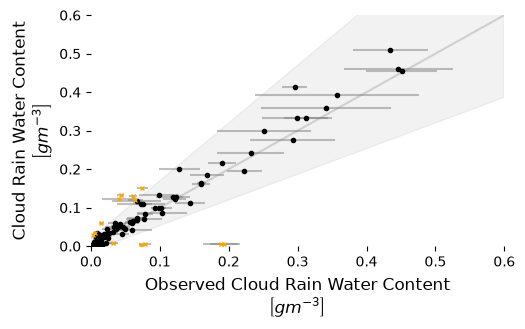

In [16]:
fig, ax = plt.subplots()

cloud_ids = ds_cleo_null["cloud_id"].data
x = np.geomspace(1e-9, 0.6, 100)
ax.fill_between(
    x,
    lower(x),
    upper(x),
    color="grey",
    alpha=0.1,
    zorder=1,
)
ax.plot(
    x,
    x,
    color="grey",
    alpha=0.3,
    zorder=2,
)
ax.set_xlim(0, 0.6)
ax.set_ylim(0, 0.6)

x = identified_clusters["mean_rain_water_content"].sel(cloud_id=cloud_ids)
x.attrs["long_name"] = "Observed Cloud Rain Water Content"
xerr = identified_clusters["sem_rain_water_content"].sel(cloud_id=cloud_ids)
y = (
    ds_cleo_null["cloud_liquid_water_content"]
    .sel(microphysics="null_microphysics")
    .sel(cloud_id=cloud_ids)
)
yerr = y * 0

ax.errorbar(
    x=x,
    y=y,
    xerr=xerr,
    yerr=yerr,
    label="All clouds",
    color="gray",
    marker="None",
    linestyle="None",
    alpha=0.5,
    zorder=3,
)

ax.set_xlabel(label_from_attrs(x, linebreak=True))
ax.set_ylabel(label_from_attrs(y, linebreak=True))

mask = (x > lower(y)) & (x < upper(y))
rwc_valid_ids = x["cloud_id"].where(mask, drop=True).data
rwc_invalid_ids = x["cloud_id"].where(~(mask), drop=True).data
print(rwc_valid_ids.size, "out of", len(x))

ax.scatter(
    x=x.sel(cloud_id=rwc_valid_ids),
    y=y.sel(cloud_id=rwc_valid_ids),
    color="k",
    marker=".",
    zorder=3,
)
ax.plot(
    x.sel(cloud_id=rwc_invalid_ids),
    y.sel(cloud_id=rwc_invalid_ids),
    linestyle="None",
    color="orange",
    marker="x",
    markersize=3,
    zorder=3,
)

set_rwc_invalid_ids = set(rwc_invalid_ids.astype(int))
print(f"The following clouds have invalid rain water content {set_rwc_invalid_ids}")

## Combine and visualize outliers

In [17]:
do_write = True
exclude_rwc_invalid = True

all_cloud_ids = set(ds["cloud_id"].data.astype(int).tolist())

if do_write:
    invalid_data_cloud_ids = invalid_combined_dataset_ids.union(error_combined_dataset_ids).union(
        invalid_derivate_mass_conservation_ids
    )
    invalid_value_cloud_ids = invalid_cloud_base_precipitation_ids.union(
        invalid_column_integrated_evaporation_ids
    )
    if exclude_rwc_invalid:
        set_invalid_cloud_ids = invalid_data_cloud_ids.union(invalid_value_cloud_ids).union(set_rwc_invalid_ids)
    else:
        set_invalid_cloud_ids = invalid_data_cloud_ids.union(invalid_value_cloud_ids)

    # remove invalid clouds
    set_valid_cloud_ids = all_cloud_ids - set_invalid_cloud_ids
    valid_cloud_ids = sorted(set_valid_cloud_ids)

    with open(
        data_dir / Path("valid_cloud_ids.yaml"),
        "w",
    ) as f:
        f.write(
            textwrap.dedent(
                f"""\
        # The following cloud ids are valid for the CLEO data
        # and can be used for the analysis
        valid_cloud_ids:
        """
            )
        )
        for _id in valid_cloud_ids:
            f.write(f" - {_id}\n")

    print("writing to:", data_dir / Path("valid_cloud_ids.yaml"))
    print(f"Number of cloud with valid CLEO data is {len(valid_cloud_ids)} of {len(all_cloud_ids)}")

# load valid cloud ids
yaml = YAML(typ="safe")  # default, if not specfied, is 'rt' (round-trip)
d = yaml.load(data_dir / Path("valid_cloud_ids.yaml"))
valid_cloud_ids = d["valid_cloud_ids"]

print("loading from:", data_dir / Path("valid_cloud_ids.yaml"))
print(f"Number of cloud with valid CLEO data is {len(valid_cloud_ids)} of {len(all_cloud_ids)}")

writing to: /work/mh1126/m300950/rain-evap-nils/sdm-eurec4a-CLEO/data/output_v4.2/valid_cloud_ids.yaml
Number of cloud with valid CLEO data is 91 of 127
loading from: /work/mh1126/m300950/rain-evap-nils/sdm-eurec4a-CLEO/data/output_v4.2/valid_cloud_ids.yaml
Number of cloud with valid CLEO data is 91 of 127


1.84 $\pm$ 5.43 $mm \, h^{-1}$ 0.39 $\pm$ 0.56 $mm \, h^{-1}$


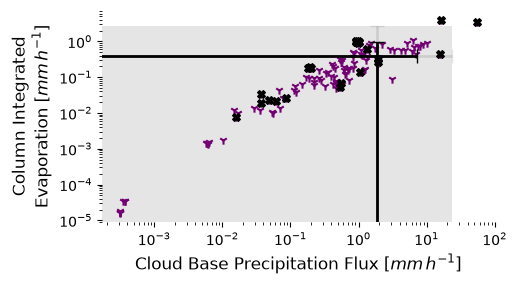

In [18]:
fig, ax = plt.subplots()

x = ds_error["inflow_precipitation"].sel(microphysics="condensation")
x_sem = ds_error_sem["inflow_precipitation"].sel(microphysics="condensation")
# x_sem = x * 0
x_mean = x.mean("cloud_id")
x_std = propagate_mean_std(x, x_sem, dim="cloud_id")

y = -ds["source_precipitation"].sel(microphysics="condensation")
y_sem = -ds_sem["source_precipitation"].sel(microphysics="condensation")
y_mean = y.mean("cloud_id")
y_std = propagate_mean_std(y, y_sem, dim="cloud_id")

style = microphysics_styles.get_style("condensation")
ax.scatter(
    x.sel(cloud_id=sorted(set_invalid_cloud_ids)),
    y.sel(cloud_id=sorted(set_invalid_cloud_ids)),
    color="k",
    marker="X",
    s=30,
    zorder=10,
)

scatter_and_errorbar(
    ax=ax,
    x_var="inflow_precipitation",
    y_var="source_precipitation",
    ds=ds,
    ds_sem=ds_sem,
    x_multiply=1.0,
    y_multiply=-1.0,
    plot_patch=True,
    plot_annotations=True,
    patch_width=4,
)

# ax.set_xlim(0, None)
# ax.set_ylim(0, None)
# ax.set_xscale('linear')
# ax.set_yscale('linear')

# ax.set_xlim(1e-3, 70)
# ax.set_ylim(1e-3, 5)
ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(label_from_attrs(x))
ax.set_ylabel(label_from_attrs(y, name_width=25))
fig.tight_layout()

save_figure(fig, appendix_fig_dir / "outlier_scatter")

## Remove outliers from all used datasets

By excluding the two outlier clouds, from our set of 117 valid clouds, we omit 2 outliers based on the mean +- 4 std.

Thus, we focus on 98.3% of clouds. 

In [19]:
print(f"Number of cloud with valid CLEO data is {len(valid_cloud_ids)} of {len(all_cloud_ids)}")
print(f"{len(valid_cloud_ids) / len(all_cloud_ids) * 100:.2f}% of the clouds have valid CLEO data")

Number of cloud with valid CLEO data is 91 of 127
71.65% of the clouds have valid CLEO data


In [20]:
ds_eulerian = ds_eulerian.sel(cloud_id=valid_cloud_ids)
ds_conservation = ds_conservation.sel(cloud_id=valid_cloud_ids)

ds = ds.sel(cloud_id=valid_cloud_ids)
ds_sem = ds_sem.sel(cloud_id=valid_cloud_ids)

ds_normalized = ds_normalized.sel(cloud_id=valid_cloud_ids)
ds_normalized_sem = ds_normalized_sem.sel(cloud_id=valid_cloud_ids)

ds_cleo_null = ds_cleo_null.sel(cloud_id=valid_cloud_ids)
ds_cleo_sem_null = ds_cleo_sem_null.sel(cloud_id=valid_cloud_ids)

identified_clusters = identified_clusters.sel(cloud_id=valid_cloud_ids)
print(f"Number of clouds after removing invalid data: {len(ds['cloud_id'])}")

Number of clouds after removing invalid data: 91


In [21]:
# ds_no_ventilation = ds_no_ventilation.sel(cloud_id=valid_cloud_ids)
# ds_sem_no_ventilation = ds_sem_no_ventilation.sel(cloud_id=valid_cloud_ids)

valid_cloud_ids_no_ventilation = [
    cid for cid in valid_cloud_ids if cid in ds_no_ventilation.cloud_id.values
]

ds_no_ventilation = ds_no_ventilation.sel(cloud_id=valid_cloud_ids_no_ventilation)
ds_sem_no_ventilation = ds_sem_no_ventilation.sel(cloud_id=valid_cloud_ids_no_ventilation)

## add some more data vars to the ds

In [22]:
ds["cloud_base_height"] = ds["gridbox_coord3"].sel(gridbox=ds["max_gridbox"])
ds["cloud_base_height"].attrs = {
    "long_name": "Cloud base height",
    "units": ds["gridbox_coord3"].attrs["units"],
}
ds["relative_humidity_mean"] = (
    ds["relative_humidity"] * ds["gridbox_volume"] / ds["gridbox_volume"].sum("gridbox")
).sum("gridbox")
ds["relative_humidity_mean"].attrs = {
    "long_name": "Mean relative humidity",
    "units": ds["relative_humidity"].attrs["units"],
}

# Calculate mean evaporation height
# for each gridbox the evaporation energy is given by E * V
ev = ds["evaporation_rate_energy"] * ds["gridbox_volume"]
# MEH is then the height average weighted by E * V.
# We need to weight, because the gridbox volume is not constant along the vertical
meh = ((ds["gridbox_coord3"] * ev) / ev.sum("gridbox")).sum("gridbox")
meh = meh / ds["gridbox_coord3"].sel(gridbox=ds["max_gridbox"])

ds["mean_evaporation_height"] = meh
ds["mean_evaporation_height"].attrs = dict(
    long_name="Mean evaporation height",
    units=ds_normalized["normalized_gridbox_coord3"].attrs["units"],
)

ds["radius_bins"].attrs.update(
    long_name="Radius",
    units="µm",
)

# update the name and units for the xi temporal mean
radius_bin_width = (ds["radius_bins"].shift(radius_bins=-1) - ds["radius_bins"].shift(radius_bins=1)) / 2
radius_bin_width = radius_bin_width.interpolate_na(dim="radius_bins", method="linear")
ds["radius_bin_width"] = radius_bin_width
ds["radius_bin_width"].attrs = dict(
    long_name="Radius bin width",
    units="µm",
    description="Width of the radius bin given by a linear interpolation of the radius bins",
)

ds["number_concentration"] = ds["xi_temporal_mean"] / ds["gridbox_volume"] / ds["radius_bin_width"]
ds["number_concentration"].attrs = dict(
    long_name="Number concentration",
    units="m^{-3} µm^{-1}",
)

# Correlations

### Calculate correlation coefficients

linear

In [23]:
correlation_vars = (
    "cloud_mass_radius_mean",
    "cloud_liquid_water_content",
    "inflow_precipitation",
    "inflow_energy",
    "relative_humidity_mean",
    "cloud_base_height",
)

correlated_var = -ds["source_precipitation"]
correlations = dict()
for var in correlation_vars:
    x = ds[var]
    correlation = xr.corr(correlated_var, x, dim="cloud_id")
    correlations[var] = correlation

# store correlations in dataset
ds_correlations_CIE = xr.Dataset(correlations)

correlated_var = ds["evaporation_fraction"]
correlations = dict()
for var in correlation_vars:
    x = ds[var]
    correlation = xr.corr(correlated_var, x, dim="cloud_id")
    correlations[var] = correlation

# store correlations in dataset
ds_correlations_EF = xr.Dataset(correlations)

correlated_var = ds["mean_evaporation_height"]
correlations = dict()
for var in correlation_vars:
    x = ds[var]
    correlation = xr.corr(correlated_var, x, dim="cloud_id")
    correlations[var] = correlation

# store correlations in dataset
ds_correlations_MEH = xr.Dataset(correlations)

logarithmic

In [24]:
correlation_vars = (
    "cloud_mass_radius_mean",
    "cloud_liquid_water_content",
    "inflow_precipitation",
    "inflow_energy",
    "relative_humidity_mean",
    "cloud_base_height",
)

correlated_var = -ds["source_precipitation"]
correlations = dict()
for var in correlation_vars:
    x = ds[var]
    correlation = xr.corr(np.log(correlated_var), np.log(x), dim="cloud_id")
    correlations[var] = correlation

# store correlations in dataset
ds_correlations_log_CIE = xr.Dataset(correlations)

correlated_var = ds["evaporation_fraction"]
correlations = dict()
for var in correlation_vars:
    x = ds[var]
    correlation = xr.corr(np.log(correlated_var), np.log(x), dim="cloud_id")
    correlations[var] = correlation

# store correlations in dataset
ds_correlations_log_EF = xr.Dataset(correlations)

correlated_var = ds["mean_evaporation_height"]
correlations = dict()
for var in correlation_vars:
    x = ds[var]
    correlation = xr.corr(np.log(correlated_var), np.log(x), dim="cloud_id")
    correlations[var] = correlation

# store correlations in dataset
ds_correlations_log_MEH = xr.Dataset(correlations)

# Data and Methods



## Fitting

In [25]:
# load dropsonde dataset
dropsonde = xr.open_dataset(
    OBS_data_dir / Path("observation/dropsonde/processed/drop_sondes.nc"),
)

# load dropsonde distances dataset
ds_distances = xr.open_dataset(
    OBS_data_dir
    / Path("observation/combined/distance/distance_dropsondes_identified_clusters_rain_mask_5.nc"),
)

# load cloud composite dataset
cloud_composite = xr.open_dataset(
    OBS_data_dir / Path("observation/cloud_composite/processed/cloud_composite_SI_units_20241025.nc"),
)

cloud_composite["radius2D"] = cloud_composite["radius"].expand_dims(time=cloud_composite["time"])
cloud_composite = cloud_composite.transpose("radius", ...)
cloud_composite = cloud_composite.sel(radius=slice(10e-6, None))

identified_clusters = identified_clusters.where(
    (
        (identified_clusters.duration.dt.seconds >= 3)
        & (identified_clusters.altitude < 1200)
        & (identified_clusters.altitude > 500)
    ),
    drop=True,
)

##### Obtain Fit Parameters from files

In [26]:
ds_parameters = xr.open_dataset(input_data_dir / "particle_size_distribution_parameters.nc")
ds_parameters_linear = xr.open_dataset(
    input_data_dir / "particle_size_distribution_parameters_linear_space.nc"
)

In [27]:
radius = np.geomspace(50e-6, 3e-3, 100)
# create radius test DataArray with radius as dimension and cloud_id as coordinate
# this dataset will be used to compute the fitted distributions
t_test = xr.DataArray(
    radius,
    dims="radius",
    coords={"radius": radius},
)
t_test = t_test.expand_dims(cloud_id=ds["cloud_id"])

# weight bin width for log spaced bins
w_test = (t_test["radius"].shift(radius=-1) - t_test["radius"].shift(radius=1)) / 2
w_test = w_test.interpolate_na("radius", method="linear", fill_value="extrapolate")

In [28]:
# fit the double log-normal distribution
ds_fitted: xr.DataArray = smodels.double_ln_normal_distribution(
    t=t_test,
    mu1=ds_parameters["mu1"],
    mu2=ds_parameters["mu2"],
    sigma1=ds_parameters["sigma1"],
    sigma2=ds_parameters["sigma2"],
    scale_factor1=ds_parameters["scale_factor1"],
    scale_factor2=ds_parameters["scale_factor2"],
)  # type: ignore

# multiply fitted psd with bin width to get number concentration and then compute the mass size distribution
fitted_psd = ds_fitted * w_test
fitted_msd = msd_from_psd_dataarray(ds_fitted * w_test)

In [29]:
# fit the double log-normal distribution
ds_fitted_linear: xr.DataArray = smodels.double_log_normal_distribution_all(
    x=t_test,  # type: ignore
    mu1=ds_parameters_linear["geometric_mean1"],  # type: ignore
    mu2=ds_parameters_linear["geometric_mean2"],  # type: ignore
    sigma1=ds_parameters_linear["geometric_std_dev1"],  # type: ignore
    sigma2=ds_parameters_linear["geometric_std_dev2"],  # type: ignore
    scale1=ds_parameters_linear["scale_factor1"],  # type: ignore
    scale2=ds_parameters_linear["scale_factor2"],  # type: ignore
    parameter_space="geometric",
    x_space="linear",
)  # type: ignore

# multiply fitted psd with bin width to get number concentration and then compute the mass size distribution
fitted_linear_psd = ds_fitted_linear * w_test
fitted_linear_msd = msd_from_psd_dataarray(ds_fitted_linear * w_test)

In [30]:
# compute the fitted potential temperature profile
ds_potential_temperature_parameters = xr.open_dataset(
    input_data_dir / "potential_temperature_parameters.nc"
)
ds_pressure_parameters = xr.open_dataset(input_data_dir / "pressure_parameters.nc")
ds_relative_humidity_parameters = xr.open_dataset(input_data_dir / "relative_humidity_parameters.nc")

In [31]:
da_potential_temperature: xr.DataArray = smodels.split_linear_func(
    x=dropsonde["altitude"],  # type: ignore
    f_0=ds_potential_temperature_parameters["f_0"],  # type: ignore
    slope_1=ds_potential_temperature_parameters["slope_1"],  # type: ignore
    slope_2=ds_potential_temperature_parameters["slope_2"],  # type: ignore
    x_split=ds_potential_temperature_parameters["x_split"],  # type: ignore
)  # type: ignore
da_potential_temperature = da_potential_temperature.sel(altitude=slice(0, 1200))

da_relative_humidity: xr.DataArray = smodels.split_linear_func(
    x=dropsonde["altitude"],  # type: ignore
    f_0=ds_relative_humidity_parameters["f_0"],  # type: ignore
    slope_1=ds_relative_humidity_parameters["slope_1"],  # type: ignore
    slope_2=ds_relative_humidity_parameters["slope_2"],  # type: ignore
    x_split=ds_relative_humidity_parameters["x_split"],  # type: ignore
)
da_relative_humidity = da_relative_humidity.sel(altitude=slice(0, 1200))

da_pressure: xr.DataArray = smodels.linear_func(
    x=dropsonde["altitude"],  # type: ignore
    slope=ds_pressure_parameters["slope"],  # type: ignore
    f_0=ds_pressure_parameters["f_0"],  # type: ignore
)
da_pressure = da_pressure.sel(altitude=slice(0, 1200))

<!-- # Random cloud example -->

In [32]:
def plot_4_all(cloud_id, pressure_reference):

    fig, axs = plt.subplot_mosaic(
        [
            [
                "ax_pt",
                "ax_rh",
            ],
            [
                "ax_psd",
                "ax_lwc",
            ],
        ],
        figsize=large_square_fig_size,
        layout="constrained",
    )

    ax_psd: plt.Axes = axs["ax_psd"]
    ax_lwc: plt.Axes = axs["ax_lwc"]
    ax_pt: plt.Axes = axs["ax_pt"]
    ax_rh: plt.Axes = axs["ax_rh"]

    # PARTICLE SIZE DISTRIBUTION

    ds_observed_cloud = match_clouds_and_cloudcomposite(
        ds_clouds=identified_clusters.sel(cloud_id=cloud_id),
        ds_cloudcomposite=cloud_composite,
    )

    ds_dropsonde_cloud = match_clouds_and_dropsondes(
        ds_clouds=identified_clusters.sel(cloud_id=cloud_id),
        ds_sonde=dropsonde,
        ds_distance=ds_distances,
        max_temporal_distance=np.timedelta64("3", "h"),
        max_spatial_distance=100,
    )
    ds_dropsonde_cloud = ds_dropsonde_cloud.sel(altitude=slice(0, 1200))

    x_observed = ds_observed_cloud["radius"] * 1e6
    y_observed = ds_observed_cloud["particle_size_distribution"]

    ds_cleo_cloud = ds_cleo_null.sel(gridbox=ds_cleo_null["max_gridbox"])
    ds_cleo_cloud = ds_cleo_cloud.sel(cloud_id=cloud_id)
    x_cleo = ds_cleo_cloud["radius_bins"]

    w_cleo = (x_cleo.shift(radius_bins=-1) - x_cleo.shift(radius_bins=1)) / 2
    w_cleo = w_cleo.interpolate_na("radius_bins", method="linear", fill_value="extrapolate")
    w_cleo = w_cleo * 1e-6  # convert µm to m

    y_cleo = ds_cleo_cloud["xi_temporal_mean"] / w_cleo / ds_cleo_cloud["gridbox_volume"]
    y_cleo = y_cleo.isel(microphysics=0)
    y_cleo.attrs.update(
        units="m^{-3} m^{-1}",
        long_name="Number concentration",
    )

    ds_fitted_cloud = ds_fitted_linear.sel(cloud_id=cloud_id)
    y_fitted = ds_fitted_cloud
    x_fitted = ds_fitted_cloud["radius"] * 1e6
    # ax_psd.set_title("Observed PSD")

    # plot observed and fitted PSD
    ax_psd.plot(
        x_observed,
        y_observed,
        linestyle="",
        marker=".",
        markersize=2,
        color=[0.5, 0.5, 0.5],
        alpha=0.3,
    )
    ax_psd.plot(
        x_observed,
        y_observed.mean("time"),
        linestyle="",
        linewidth=1,
        marker=".",
        markersize=4,
        color=[0.3, 0.3, 0.3],
        alpha=0.75,
        label="Mean. Obs.",
    )

    # ax_psd.plot(
    #     x_cleo,
    #     y_cleo.T,
    #     linestyle="--",
    #     color=[0.1,0.1,0.1],
    #     lw=2,
    #     label="CLEO",
    # )

    ax_psd.plot(
        x_fitted,
        y_fitted.T,
        linestyle="-",
        color=[0.1, 0.1, 0.1],
        lw=2,
        label="Fit",
    )

    ax_psd.set_xscale("log")
    ax_psd.set_yscale("symlog", linthresh=0.5, linscale=0.3)
    ax_psd.set_ylim(-0.5, 1e13)
    # ax_psd.set_ylim(0, 20e6)
    # ax_psd.set_xlim(0, 3000)
    # ax_psd.set_ylim(0, 5e6)
    ax_psd.set_xlabel(r"Radius $[\mu m]$")
    ax_psd.set_ylabel(r"Number Concentration $[m^{-3} m^{-1}]$")

    # DROPSONDE

    # ----------------------
    # Liquid Water Content
    # ----------------------

    x = identified_clusters["mean_rain_water_content"]
    xerr = identified_clusters["sem_rain_water_content"]
    y = ds_cleo_null["cloud_liquid_water_content"].sel(microphysics="null_microphysics")
    yerr = ds_cleo_sem_null["cloud_liquid_water_content"].sel(microphysics="null_microphysics")

    y.attrs.update(long_name="Model " + y.attrs["long_name"])

    # indices = (x != 0) & (y != 0)

    # x, xerr, y, yerr = x[indices], xerr[indices], y[indices], yerr[indices]

    corr = xr.corr(x, y, dim="cloud_id")
    corr_loglog = xr.corr(np.log(x + 1e-28), np.log(y + 1e-28), dim="cloud_id")

    ax_lwc.scatter(
        x=x,
        y=y,
        marker=".",
        color="k",
        alpha=0.75,
        # label = f"Pearson correlation coefficient: {corr.values:.2f}"
    )

    ax_lwc.errorbar(
        x=x,
        y=y,
        xerr=xerr,
        yerr=yerr,
        fmt=".",
        color="k",
        alpha=0.1,
        # label = f"Pearson correlation coefficient: {corr.values:.2f}"
    )

    xlim = ax_lwc.get_xlim()
    ylim = ax_lwc.get_ylim()
    lim = 0, max(xlim[1], ylim[1])

    ax_lwc.set_xlim(lim)
    ax_lwc.set_ylim(lim)

    plot_one_one(ax_lwc, color="grey", linestyle="-")
    ax_lwc.set_xlabel(label_from_attrs(x, name_width=25))
    ax_lwc.set_ylabel(label_from_attrs(y, name_width=20))
    # ax.legend(loc="upper left")

    ax_lwc.annotate(
        text=f"$R = {corr.values:.2f}$\n$R_{{log}} = {corr_loglog.values:.2f}$",
        xy=(0.65, 0.1),
        xycoords="axes fraction",
        # fontsize=10,
    )

    # ----------------------
    # POTENTIAL TEMPERATURE
    # ----------------------

    y_observed = ds_dropsonde_cloud["altitude"]
    x_observed = ds_dropsonde_cloud["potential_temperature"].transpose(..., "time")

    x_cleo = potential_temperature_from_temperature_pressure(
        air_temperature=ds_cleo_null["air_temperature"].sel(cloud_id=cloud_id),
        pressure=ds_cleo_null["pressure"].sel(cloud_id=cloud_id),
        pressure_reference=pressure_reference,
    )
    y_cleo = ds_cleo_null["gridbox_coord3"].sel(cloud_id=cloud_id)

    x_fitted = da_potential_temperature.sel(cloud_id=cloud_id)
    y_fitted = da_pressure["altitude"]

    ax_pt.plot(
        x_observed,
        y_observed,
        linestyle="-",
        color=default_colors[0],
        alpha=0.3,
    )
    ax_pt.plot(
        x_observed.mean("time"),
        y_observed,
        linestyle="-",
        color=default_dark_colors[0],
        alpha=0.75,
        lw=1,
        label="Mean. Obs.",
    )
    # ax_pt.plot(
    #     x_cleo.T,
    #     y_cleo.T,
    #     linestyle="--",
    #     color=default_dark_colors[0],
    #     lw=2,
    #     label="CLEO",
    # )

    ax_pt.plot(
        x_fitted.T,
        y_fitted.T,
        linestyle="-",
        color=default_dark_colors[0],
        lw=2,
        label="Fit",
    )

    ax_pt.set_xlabel(r"Potential Temperature $[K]$")
    ax_pt.set_ylabel(r"Altitude $[m]$")

    # ----------------------
    # RELATIVE HUMIDITY
    # ----------------------

    y_observed = ds_dropsonde_cloud["altitude"]
    x_observed = ds_dropsonde_cloud["relative_humidity"].transpose(..., "time")

    x_cleo = relative_humidity_from_tps(
        temperature=ds_cleo_null["air_temperature"].sel(cloud_id=cloud_id),
        pressure=ds_cleo_null["pressure"].sel(cloud_id=cloud_id),
        specific_humidity=ds_cleo_null["specific_mass_vapour"].sel(cloud_id=cloud_id),
    )
    y_cleo = ds_cleo_null["gridbox_coord3"].sel(cloud_id=cloud_id)

    x_fitted = da_relative_humidity.sel(cloud_id=cloud_id)
    y_fitted = da_relative_humidity["altitude"]

    ax_rh.plot(
        x_observed,
        y_observed,
        linestyle="-",
        color=default_colors[1],
        alpha=0.3,
    )
    ax_rh.plot(
        x_observed.mean("time"),
        y_observed,
        linestyle="-",
        color=default_dark_colors[1],
        alpha=0.75,
        lw=1,
        label="Mean. Obs.",
    )
    # ax_rh.plot(
    #     x_cleo.T,
    #     y_cleo.T,
    #     linestyle="--",
    #     color=default_dark_colors[1],
    #     lw=2,
    #     label="CLEO",
    # )
    ax_rh.plot(
        x_fitted.T,
        y_fitted.T,
        linestyle="-",
        color=default_dark_colors[1],
        lw=2,
        label="Fit",
    )

    yticks = ax_pt.get_yticks()
    # ax_pt.set_yticks(yticks, np.full_like(yticks, "", dtype=str))
    ax_pt.set_xticks(np.arange(296, 302, 2))

    ax_rh.set_xlabel(r"Relative Humidity $[\%]$")
    # ax_rh.set_yticks(yticks, np.full_like(yticks, "", dtype=str))

    for _ax in [ax_pt, ax_rh]:
        _ax.axhline(
            ds_relative_humidity_parameters["x_split"].sel(cloud_id=cloud_id).data,
            color="red",
            linestyle=":",
        )
        _ax.axhline(ds_observed_cloud["altitude"].mean("time").data, color="k", linestyle=":")
        _ax.set_yticks(np.arange(0, 1250, 400))
        _ax.set_ylim(0, 1200)
        # _ax.tick_params(axis="x", rotation=45)

    ax_psd.legend(loc="lower left")

    ax_psd.set_title(f"Measurements {len(ds_observed_cloud['time'].data)}")
    ax_pt.set_title(f"Measurements {len(ds_dropsonde_cloud['time'].data)}")
    ax_rh.set_title(f"Measurements {len(ds_dropsonde_cloud['time'].data)}")

    # # remove all labels and spines
    # for _ax in axs:
    #     _ax.spines["top"].set_visible(False)
    #     _ax.spines["right"].set_visible(False)
    #     _ax.spines["left"].set_visible(False)
    #     _ax.spines["bottom"].set_visible(False)

    #     _ax.tick_params(
    #         axis="both",
    #         which="both",
    #         bottom=False,
    #         top=False,
    #         left=False,
    #         right=False,
    #         labelbottom=False,
    #         labelleft=False,
    #     )
    #     _ax.set_xlabel("")
    #     _ax.set_ylabel("")
    #     _ax.set_title("")

    # fig.tight_layout()
    # ax_pt.set_ylim(0, None)
    fig.suptitle(
        f"Cloud ID {cloud_id} | Pressure Ref. {pressure_reference/100:.2f} hPa | Time {ds_observed_cloud['time'].data[0].astype('datetime64[m]')}"
    )
    fig.tight_layout()
    return fig, axs

##### Fig. 1

/tmp/ipykernel_1096126/2896317584.py:324: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


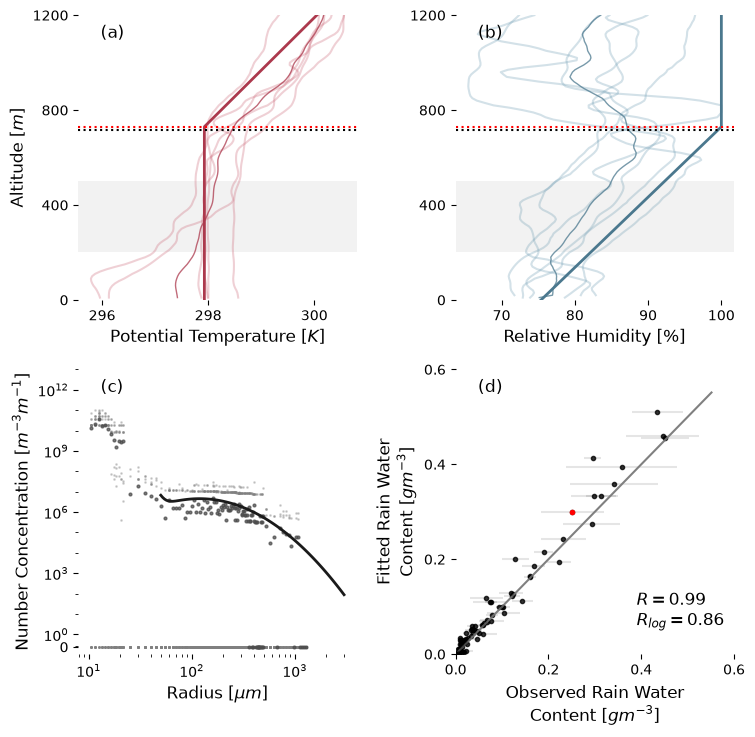

In [33]:
cloud_id = 396
fig, axs = plot_4_all(cloud_id=cloud_id, pressure_reference=100000)
add_subplotlabel(
    axs=axs.values(),
    location="upper left",
)

axs["ax_psd"].set_yticks([0, 1e0, 1e3, 1e6, 1e9, 1e12])
lwc_ticks = np.arange(0, 0.8, 0.2)
axs["ax_lwc"].set_yticks(lwc_ticks)
axs["ax_lwc"].set_xticks(lwc_ticks)
axs["ax_lwc"].set_ylabel("Fitted Rain Water\nContent " + r"$[g m^{-3}]$")
axs["ax_lwc"].set_xlabel("Observed Rain Water\nContent " + r"$[g m^{-3}]$")

axs["ax_lwc"].scatter(
    x=identified_clusters["mean_rain_water_content"].sel(cloud_id=cloud_id),
    y=ds_cleo_null["cloud_liquid_water_content"]
    .sel(microphysics="null_microphysics")
    .sel(cloud_id=cloud_id),
    marker=".",
    color="r",
    alpha=1,
    zorder=10,
)

for key in axs:
    try:
        axs[key].get_legend().remove()
    except AttributeError:
        pass

for _ax in [axs["ax_pt"], axs["ax_rh"]]:
    xlim = _ax.get_xlim()
    xy = (xlim[0], 200)
    width = xlim[1] - xlim[0]
    height = 500 - 200
    rect = mpatches.Rectangle(
        xy=xy,
        width=width,
        height=height,
        linewidth=0,
        edgecolor="None",
        facecolor=[0.5, 0.5, 0.5, 0.1],
    )

    # Add the patch to the Axes
    _ax.add_patch(rect)

fig.suptitle("")
for _ax in axs.values():
    _ax.set_title("")

fig.tight_layout()
save_figure(
    fig=fig,
    filepath=fig_dir / f"FIG-1-compare_observations_cloud_{cloud_id}",
)

## Precipitation

##### Fig. 2

We want to show the stationary state of the simulation.
And we want to show the values of precipitation to show the errors.

/home/m/m300950/mamba/envs/sdm_eurec4a_env312/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


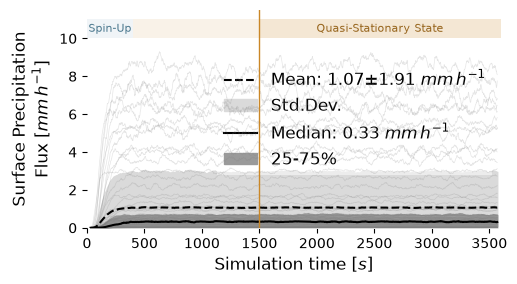

In [34]:
rolling_indices = 30
xlim = (0, 3600)
ylim = (0, 11.5)

fig, ax = plt.subplots()
ax: plt.Axes = ax
# ax_hist.sharey(ax)

x = ds_conservation["time"]

y = -ds_conservation["outflow_precipitation"].transpose("time", ...)
y_rolling = y.rolling(time=rolling_indices, center=True).mean()
x_rolling = x.rolling(time=rolling_indices, center=True).mean()

y_mean, y_sem = mean_and_stderror_of_mean(y.sel(time=TimeSlices.quasi_stationary_state), dims=("time",))

total_mean = y_mean.mean("cloud_id")
total_std = propagate_mean_std(data=y_mean, data_std=y_sem, dim="cloud_id")

total_median = y_mean.median("cloud_id")

x = x.isel(time=slice(0, -2))
y = y.isel(time=slice(0, -2))

ax.plot(
    x_rolling,
    y_rolling,
    color="grey",
    alpha=0.2,
    linewidth=0.5,
    zorder=10,
)

ax.plot(
    x_rolling,
    y_rolling.mean("cloud_id"),
    color="k",
    alpha=1,
    linestyle="--",
    zorder=10,
    label=rf"Mean: {total_mean.data:.2f}$\pm${total_std.data:.2f} ${y.attrs['units']}$",
)
ax.fill_between(
    x_rolling,
    y_rolling.mean("cloud_id") + y_rolling.std("cloud_id"),
    y_rolling.mean("cloud_id") - y_rolling.std("cloud_id"),
    label="Std.Dev.",
    color=adjust_lightness("grey", 1.7),
    alpha=1,
    zorder=3,
)


ax.plot(
    x_rolling,
    y_rolling.median("cloud_id"),
    color="k",
    alpha=1,
    linestyle="-",
    zorder=10,
    label=rf"Median: {total_median.data:.2f} ${y.attrs['units']}$",
)

ax.fill_between(
    x_rolling,
    y_rolling.quantile(0.25, "cloud_id"),
    y_rolling.quantile(0.75, "cloud_id"),
    label=f"25-75%",
    color=adjust_lightness("grey", 1.2),
    alpha=1,
    zorder=4,
)


ax.fill_betweenx(
    [10, 11],
    400,
    TimeSlices.quasi_stationary_state.stop,
    color=default_colors[2],
    alpha=0.1,
    edgecolor="none",
)
ax.fill_betweenx(
    [10, 11],
    TimeSlices.quasi_stationary_state.start,
    TimeSlices.quasi_stationary_state.stop,
    color=default_colors[2],
    alpha=0.1,
    edgecolor="none",
)
ax.annotate(
    text="Quasi-Stationary State",
    xy=(
        (TimeSlices.quasi_stationary_state.start + TimeSlices.quasi_stationary_state.stop) / 2,
        10.5,
    ),
    ha="center",
    va="center",
    fontsize=8,
    color=default_dark_colors[2],
)
ax.fill_betweenx(
    [10, 11],
    0,
    400,
    color=default_colors[1],
    alpha=0.1,
    edgecolor="none",
)
ax.annotate(
    text="Spin-Up",
    xy=(
        (0 + 400) / 2,
        10.5,
    ),
    ha="center",
    va="center",
    fontsize=8,
    color=default_dark_colors[1],
)

ax.set_ylim(ylim)
ax.set_ylabel(label_from_attrs(y, name_width=25))
ax.set_xlabel(r"Simulation time $[s]$")
ax.set_xlim(xlim)
# ax.set_yticks(yticks)
ax.legend(loc="center right")

ax.axvline(
    TimeSlices.quasi_stationary_state.start,
    color=default_colors[2],
    linestyle="-",
    linewidth=1,
    alpha=1,
    zorder=20,
    label="Stationary State",
)

fig.tight_layout()
save_figure(fig=fig, filepath=fig_dir / f"FIG-2-precipitation-temporal-evolution-stationary-state-all")

## Individual histograms

##### Fig. 3

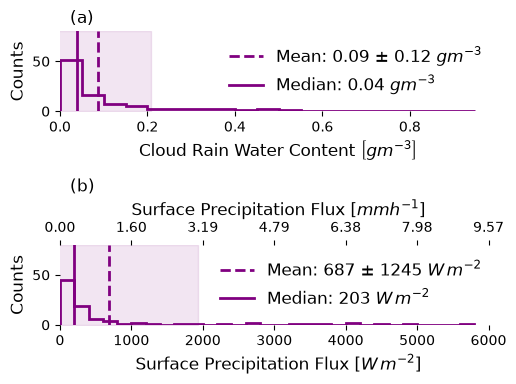

In [35]:
fig, axs = plt.subplots(ncols=1, nrows=2, figsize=(5.33, 4))

ylim = (0, 80)
ax_x_hist: plt.Axes = axs[0]
ax_y_hist: plt.Axes = axs[1]

x = ds["cloud_liquid_water_content"]
x_sem = ds_sem["cloud_liquid_water_content"]
y = -ds["outflow_energy"]
y_sem = -ds_sem["outflow_energy"]

x_mean = x.mean("cloud_id")
x_std = propagate_mean_std(x, x_sem, dim="cloud_id")

y_mean = y.mean("cloud_id")
y_std = propagate_mean_std(y, y_sem, dim="cloud_id")

x_median = x.median("cloud_id")
y_median = y.median("cloud_id")

x_bins = np.arange(0, 1, 0.05)
y_bins = np.arange(0, 6000, 200)

x_dict = dict(
    data=x,
    mean=x_mean,
    std=x_std,
    median=x_median,
    bins=x_bins,
)
y_dict = dict(
    data=y,
    mean=y_mean,
    std=y_std,
    median=y_median,
    bins=y_bins,
)

for mp in ["condensation"]:
    style = microphysics_styles.get_style(mp)
    for d, _ax, rounding in zip([x_dict, y_dict], [ax_x_hist, ax_y_hist], [2, 0]):

        units = d["data"].attrs.get("units", "")
        units = rf"${units}$"

        median = d["median"].sel(microphysics=mp)
        m, s = d["mean"].sel(microphysics=mp), d["std"].sel(microphysics=mp)

        # round values for display
        m_rounded = np.round(m, rounding)
        s_rounded = np.round(s, rounding)
        median_rounded = np.round(median, rounding)

        # if rounded value is integer, convert to int for display
        if rounding == 0:
            m_rounded = m_rounded.astype(int)
            s_rounded = s_rounded.astype(int)
            median_rounded = median_rounded.astype(int)

        _ax.hist(
            d["data"].sel(microphysics=mp),
            bins=d["bins"],
            histtype="step",
            color=style["color"],
            lw=2,
        )
        _ax.axvline(
            m,
            color=style["color"],
            linestyle="--",
            lw=2,
            label=rf"Mean: {m_rounded.data} $\pm$ {s_rounded.data} {units}",
        )
        _ax.fill_betweenx(
            ylim,
            m - s,
            m + s,
            color=style["color"],
            alpha=0.1,
        )
        _ax.axvline(
            median,
            color=style["color"],
            linestyle="-",
            lw=2,
            label=f"Median: {median_rounded.data} {units}",
        )

ax_x_hist.set_xlabel(label_from_attrs(x))
ax_y_hist.set_xlabel(label_from_attrs(y))

# ax_y_hist.set_xticks(np.arange(0, 17, 2))
for _ax in axs.flatten():
    _ax.set_ylabel("Counts")
    _ax.set_ylim(ylim)
    _ax.legend(loc="upper right")
    _ax.set_xlim(0, None)

y_ticks = xr.DataArray(ax_y_hist.get_xticks(), attrs=y.attrs.copy())
new_y_ticks: xr.DataArray = conversions.EvaporationUnits(data=y_ticks, input_type="energy").convert_to(
    "precipitation"
)
new_ticks_func = lambda _: [f"{round(new_x, 2):.2f}" for x, new_x in zip(y_ticks, new_y_ticks.data)]
add_additional_axis(
    ax=ax_y_hist,
    new_ticks_func=new_ticks_func,
    label=label_from_attrs(da=new_y_ticks),
    position="top",
    offset_position=["axes", 1],
)


add_subplotlabel([ax_x_hist, ax_y_hist], location="title", zorder=100)

fig.tight_layout()
save_figure(fig=fig, filepath=fig_dir / f"FIG-3-{x.name}-{y.name}-histograms-LINEAR")

# Results

## Analysis of EvapOnly

### Evaporation fraction and Column Integrated Evaporation comparison


Validate that match exactly. 
This will give us confidence in our analysis. 

<xarray.DataArray (microphysics: 4)> Size: 32B
array([1., 1., 1., 1.])
Coordinates:
  * microphysics  (microphysics) object 32B 'condensation' ... 'coalbure_cond...
Attributes:
    units:    mm \, h^{-1}


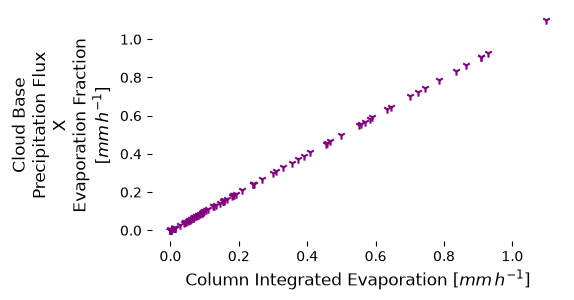

In [36]:
x = -ds["source_precipitation"]
y = ds["inflow_precipitation"] * ds["evaporation_fraction"] * 1e-2

long_name = label_from_attrs(ds["inflow_precipitation"], name_width=20, return_units=False)
long_name += "\nX\n"
long_name += label_from_attrs(ds["evaporation_fraction"], name_width=20, return_units=False)

y.attrs.update(
    long_name=long_name,
    units=ds["inflow_precipitation"].attrs["units"],
)

plt.scatter(
    x.sel(microphysics="condensation"),
    y.sel(microphysics="condensation"),
    **microphysics_styles.get_style("condensation"),
)
plt.xlabel(label_from_attrs(x))
plt.ylabel(label_from_attrs(y, linebreak=True))
print(xr.corr(x, y, dim="cloud_id"))

##### Fig. 4

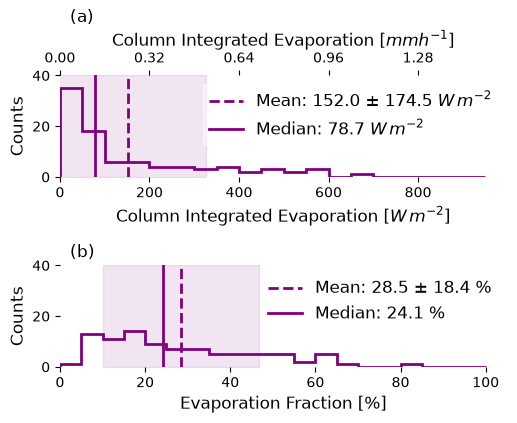

In [37]:
fig, axs = plt.subplots(ncols=1, nrows=2, figsize=(5.33, 4.4))

ylim = (0, 40)
ax_x_hist: plt.Axes = axs[0]
ax_y_hist: plt.Axes = axs[1]

x = -ds["source_energy"]
x_sem = -ds_sem["source_energy"]

y = ds["evaporation_fraction"]
y_sem = ds_sem["evaporation_fraction"]

x_mean = x.mean("cloud_id")
x_std = propagate_mean_std(x, x_sem, dim="cloud_id")

y_mean = y.mean("cloud_id")
y_std = propagate_mean_std(y, y_sem, dim="cloud_id")

x_median = x.median("cloud_id")
y_median = y.median("cloud_id")

x_bins = np.arange(0, 1000, 50)
y_bins = np.arange(0, 101, 5)

x_dict = dict(
    data=x,
    mean=x_mean,
    std=x_std,
    median=x_median,
    bins=x_bins,
)
y_dict = dict(
    data=y,
    mean=y_mean,
    std=y_std,
    median=y_median,
    bins=y_bins,
)

for mp in ["condensation"]:
    style = microphysics_styles.get_style(mp)
    for d, _ax, rounding in zip([x_dict, y_dict], [ax_x_hist, ax_y_hist], [1, 1]):

        units = d["data"].attrs.get("units", "")
        units = rf"${units}$"

        median = d["median"].sel(microphysics=mp)
        m, s = d["mean"].sel(microphysics=mp), d["std"].sel(microphysics=mp)

        # round values for display
        m_rounded = np.round(m, rounding)
        s_rounded = np.round(s, rounding)
        median_rounded = np.round(median, rounding)

        # if rounded value is integer, convert to int for display
        if rounding == 0:
            m_rounded = m_rounded.astype(int)
            s_rounded = s_rounded.astype(int)
            median_rounded = median_rounded.astype(int)

        _ax.hist(
            d["data"].sel(microphysics=mp),
            bins=d["bins"],
            histtype="step",
            color=style["color"],
            lw=2,
        )
        _ax.axvline(
            m,
            color=style["color"],
            linestyle="--",
            lw=2,
            label=rf"Mean: {m_rounded.data} $\pm$ {s_rounded.data} {units}",
        )
        _ax.fill_betweenx(
            ylim,
            m - s,
            m + s,
            color=style["color"],
            alpha=0.1,
        )
        _ax.axvline(
            median,
            color=style["color"],
            linestyle="-",
            lw=2,
            label=f"Median: {median_rounded.data} {units}",
        )

ax_x_hist.set_xlabel(label_from_attrs(x))
ax_y_hist.set_xlabel(label_from_attrs(y))

for _ax in axs.flatten():
    _ax.set_ylabel("Counts")
    _ax.set_ylim(ylim)
    _ax.legend(loc="upper right")
    _ax.set_xlim(0, None)

add_subplotlabel([ax_x_hist, ax_y_hist], location="title", zorder=100)

# update the title to be on the left
ax_x_hist.set_title("")

x_ticks = xr.DataArray(ax_x_hist.get_xticks(), attrs=x.attrs.copy())
new_x_ticks: xr.DataArray = conversions.EvaporationUnits(data=x_ticks, input_type="energy").convert_to(
    "precipitation"
)
new_ticks_func = lambda _: [f"{round(new_x, 2):.2f}" for x, new_x in zip(x_ticks, new_x_ticks.data)]
add_additional_axis(
    ax=ax_x_hist,
    new_ticks_func=new_ticks_func,
    label=label_from_attrs(da=new_x_ticks),
    position="top",
    offset_position=["axes", 1],
)
ax_x_hist.set_xlabel(label_from_attrs(da=x))


fig.tight_layout()
save_figure(fig=fig, filepath=fig_dir / f"FIG-4-{x.name}-{y.name}-histograms-LINEAR")

make sure the two histograms have same axes sizes

### Evaporation Profiles

##### Fig. 5

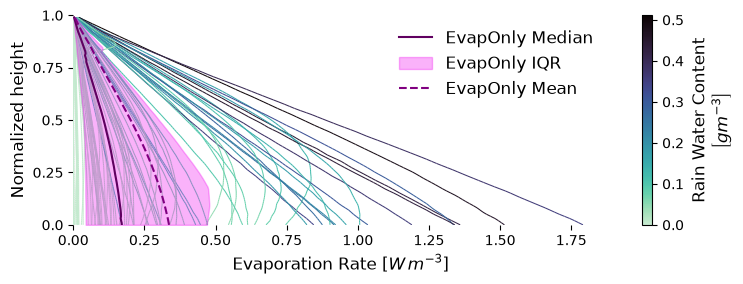

In [38]:
y_ticks = np.arange(0, 1.01, 0.25)

fig = plt.figure(figsize=wide_fig_size)
gs = fig.add_gridspec(nrows=1, ncols=1)

ax = fig.add_subplot(gs[:, :])

plot_microphysics = ["condensation"]

x = -ds_normalized["evaporation_rate_energy"]
x_sem = -ds_normalized_sem["evaporation_rate_energy"]
attrs = x.attrs.copy()
y = ds_normalized["normalized_gridbox_coord3"]

c = ds_normalized["liquid_water_content"]

norm = mcolors.Normalize(vmin=0, vmax=ds["cloud_liquid_water_content"].max().data)


for mp in plot_microphysics:
    _x = x.sel(microphysics=mp)
    _x_sem = x_sem.sel(microphysics=mp)
    _y = y

    # select all but the top most gridboxes
    _x = _x.sel(normalized_gridbox_coord3=slice(0, 0.99))
    _y = _y.sel(normalized_gridbox_coord3=slice(0, 0.99))
    _c = c.sel(normalized_gridbox_coord3=slice(0, 0.99))

    md_mean = _x.mean("cloud_id")
    md_sem = propagate_mean_std(_x, _x_sem, dim="cloud_id")
    style_full = microphysics_styles[mp].copy()

    _xx = _x
    _yy = _y.expand_dims(cloud_id=_x["cloud_id"])
    _cc = _c.sel(microphysics=mp)

    # plot colored lines of individual clouds
    # ax.plot(
    #     _x.T,
    #     _y.T,
    #     color=adjust_lightness("grey", 1.5),
    #     alpha=0.3,
    #     zorder=1,
    # )

    sc = ax.scatter(
        _xx,
        _yy,
        c=_cc,
        s=0,
        alpha=1,
        marker=".",
        cmap=strength_cmap,
        norm=norm,
    )

    for cloud_id in x["cloud_id"]:

        # gridboxes = slice(0, ds['max_gridbox'].sel(cloud_id=cloud_id, microphysics="condensation") - 1)

        # xx = np.flip(x.sel(cloud_id=cloud_id, gridbox = gridboxes).data)
        # yy = np.flip(y.sel(cloud_id=cloud_id, gridbox = gridboxes).data)
        # cc = np.flip(c.sel(cloud_id=cloud_id, gridbox = gridboxes).data)

        xx = np.flip(_xx.sel(cloud_id=cloud_id).data)
        yy = np.flip(_yy.sel(cloud_id=cloud_id).data)
        cc = np.flip(_cc.sel(cloud_id=cloud_id).data)

        rng = np.arange(0, len(xx) - 1)
        lines = [[(xx[i], yy[i]), (xx[i + 1], yy[i + 1])] for i in rng]
        colors = strength_cmap(norm(cc[rng]))

        lc = mcollections.LineCollection(segments=lines, colors=colors)  # Use a random colormap
        lc.set_linewidth(0.75)  # Set line width
        lc.set_alpha(1)  # Set line width
        ax.add_collection(lc)  # Add the line collection to the axes

    # ax.plot(
    #     _x.T,
    #     _y.T,
    #     color=adjust_lightness("grey", 1.5),
    #     alpha=0.3,
    # )

    ax.set_yticks(y_ticks)
    ax.set_yticklabels([])

    # mean and std
    # # median and IQR

    ax.plot(
        _x.median("cloud_id"),
        _y,
        label=style_full["name"] + " Median",
        color=style_full["dark_color"],
        linestyle="-",
        zorder=4,
    )
    ax.fill_betweenx(
        _y,
        _x.quantile(0.25, "cloud_id"),
        _x.quantile(0.75, "cloud_id"),
        alpha=0.3,
        color=adjust_lightness(style_full["light_color"], 1.5),
        zorder=2,
        label=style_full["name"] + " IQR",
    )

    ax.plot(
        md_mean,
        _y,
        label=style_full["name"] + " Mean",
        color=style_full["color"],
        linestyle="--",
        zorder=4,
    )

ax.set_yticks(y_ticks, y_ticks)
ax.legend(loc="upper right")
# ax.set_xscale("log")

ax.set_xlim(0, None)
ax.set_ylim(0, 1)

# ax.axvline(0, color="k", linestyle="--", alpha=1, zorder=10)
# ax.set_xscale('log')
ax.set_xlabel(label_from_attrs(x))
ax.set_ylabel(label_from_attrs(y, return_units=False, name_width=25))

fig.colorbar(sc, ax=ax, label=label_from_attrs(c, name_width=20, linebreak=True))

fig.tight_layout()

save_figure(fig, fig_dir / f"FIG-5-vertical-profiles-{x.name}-{y.name}-color-{c.name}")

### Column integrated evaporation and cloud base precipitation flux

##### Fig. 6

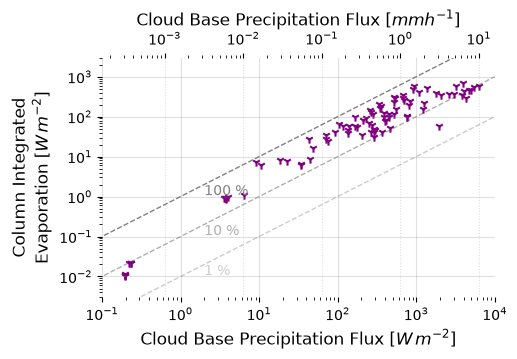

In [39]:
fig, ax = plt.subplots(1, 1, figsize=(small_fig_size[0], small_fig_size[1] * 1.25))
# ax_no_ventilation = plt.Axes = axs[1]

x = ds["inflow_energy"]
y = -ds["source_energy"]

# x_no_ventilation = ds_no_ventilation["inflow_precipitation"]
# y_no_ventilation = - ds_no_ventilation["source_precipitation"]


for mp in ["condensation"]:
    style = microphysics_styles.get_style(mp)
    ax.scatter(
        x.sel(microphysics=mp),
        y.sel(microphysics=mp),
        **style,
    )


ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(3e-3, 3e3)
ax.set_xlim(1e-1, 1e4)
xlim = np.array(ax.get_xlim())
ylim = np.array(ax.get_ylim())

lims = np.concatenate([xlim, ylim])

p_x_values = np.geomspace(lims.min(), lims.max(), 100)

values_label_size = 10

for p in [1, 0.1, 0.01]:
    style = dict(color="grey", alpha=p ** (1 / 5))
    lines = ax.plot(p_x_values, p * p_x_values, "--", linewidth=1, zorder=0, **style)
    line = lines[0]
    _x = 2e4
    _y = p * _x

    ax.annotate(
        f"{100 * p:.0f} %",
        xy=(_x, _y),
        xytext=(10, 10),
        textcoords="offset points",
        va="top",
        ha="left",
        size=values_label_size,
        **style,
    )
    _x = 2e0
    _y = p * _x

    ax.annotate(
        f"{100 * p:.0f} %",
        xy=(_x, _y),
        xytext=(0, 0),
        textcoords="offset points",
        va="top",
        ha="left",
        size=values_label_size,
        **style,
    )

x_ticks = xr.DataArray(ax.get_xticks(), attrs=x.attrs.copy())
new_x_ticks: xr.DataArray = conversions.EvaporationUnits(data=x_ticks, input_type="energy").convert_to(
    "precipitation"
)

factor = new_x_ticks / x_ticks

assert (
    np.abs(factor.std() / factor.mean()) < 1e-6
), f"Conversion factor is not constant: std={factor.std}, mean={factor.mean}"
factor = factor.mean().data

# add a second xaxis
ax2 = ax.twiny()
ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlim(factor * xlim)  # Sync the x-limits
ax2.set_ylim(ylim)  # Sync the x-limits

ax2.set_xlabel(label_from_attrs(da=new_x_ticks))
ax.grid(color="grey", alpha=0.25, linewidth=0.75)
ax2.grid(color="grey", alpha=0.25, linewidth=0.75, linestyle=":")

ax.set_xlabel(label_from_attrs(x))
ax.set_ylabel(label_from_attrs(y, name_width=20))

fig.tight_layout()

save_figure(fig=fig, filepath=fig_dir / f"FIG-6-{x.name}-{y.name}-scatter")

### Vertical Correlations

In [40]:
x_vars = ("relative_humidity", "liquid_water_content", "mass_radius_mean")

correlated_var = -ds["evaporation_rate_energy"].transpose("gridbox", ...)

correlations = dict()
for var in x_vars:
    x = ds[var].transpose("gridbox", ...)
    correlation = xr.corr(correlated_var, x, dim="gridbox")
    correlations[var] = correlation

# store correlations in dataset
ds_vertical_correlations = xr.Dataset(correlations)

##### Fig. 7

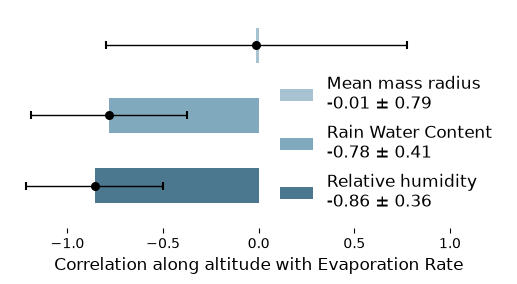

In [41]:
fig, ax = plt.subplots(figsize=small_fig_size)

keys = [
    "mass_radius_mean",
    "liquid_water_content",
    "relative_humidity",
]

labels = {
    "mass_radius_mean": label_from_attrs(ds["mass_radius_mean"], return_units=False),
    "liquid_water_content": label_from_attrs(ds["liquid_water_content"], return_units=False),
    "relative_humidity": label_from_attrs(ds["relative_humidity"], return_units=False),
}
labels["mass_radius_mean"] = "Mean mass radius"

labels_long = labels.copy()


colors = {
    "mass_radius_mean": adjust_lightness(default_colors[1], 1.3),
    "liquid_water_content": adjust_lightness(default_colors[1], 1.1),
    "relative_humidity": adjust_lightness(default_colors[1], 0.75),
}

inds = {
    "mass_radius_mean": 2,
    "liquid_water_content": 1,
    "relative_humidity": 0,
}

y = ds_vertical_correlations.sel(microphysics="condensation")
data = np.array([y[key].data for key in keys])
means, stds = y.mean("cloud_id"), y.std("cloud_id")


for key in keys:

    unit = y[key].attrs.get("units", "")

    labels_long[key] += "\n" + f"{means[key].data:.2f} " + r"$\pm$" + f" {stds[key].data:.2f} {unit}"

    m = means[key]
    s = stds[key]
    c = colors[key]
    i = inds[key]
    ax.barh(y=i, width=m, height=0.5, color=c, label=labels_long[key])

    lower = m - s
    upper = m + s
    upper, lower = max(lower, upper), min(lower, upper)

    ax.scatter(m, i, marker="o", color="k", s=30, zorder=10)
    ax.scatter(lower, i, marker="|", color="k", s=30, zorder=10)
    ax.scatter(upper, i, marker="|", color="k", s=30, zorder=10)

    ax.hlines(i, lower, upper, color="k", linestyle="-", lw=1, zorder=3)


# ax.set_xlim(-1, 1)


ax.set_xlabel(
    f"Correlation along altitude with {label_from_attrs(correlated_var, return_units = False)}",
)

# set size
yticks_size = ax.yaxis.label.get_size()


ax.set_ylim(min(inds.values()) - 0.6, max(inds.values()) + 0.5)
ax.set_yticks([])
# ax.set_yticks(list(inds.values()), list(labels_long.values()), fontsize = yticks_size)
ax.set_xticks(np.arange(-1, 1.1, 0.5))
ax.xaxis.set_tick_params(rotation=0)
ax.set_xlim(-1.3, 1.3)

ax.legend(loc="lower right")
fig.tight_layout()
save_figure(fig=fig, filepath=fig_dir / f"FIG-7-vertical-correlation-barplot")

### Total Correlations 

##### Fig XX

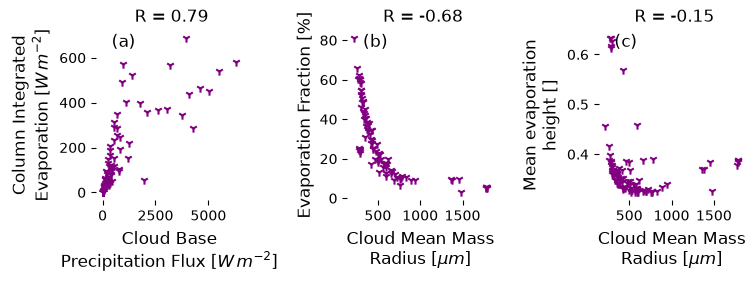

In [42]:
fig, axs = plt.subplots(ncols=3, figsize=wide_fig_size)

axs_ef: plt.Axes = axs[1]
axs_cie: plt.Axes = axs[0]
axs_meh: plt.Axes = axs[2]

y = ds["evaporation_fraction"].sel(microphysics="condensation")
x = ds["cloud_mass_radius_mean"].sel(microphysics="condensation")
correlation = ds_correlations_EF[x.name].sel(microphysics="condensation")
axs_ef.set_title(f" R = {correlation.data:.2f}")
axs_ef.scatter(
    x,
    y,
    **microphysics_styles.get_style("condensation"),
)
axs_ef.set_xlabel(label_from_attrs(x, name_width=20))
axs_ef.set_ylabel(label_from_attrs(y, name_width=20))

y = -ds["source_energy"].sel(microphysics="condensation")
x = ds["inflow_energy"].sel(microphysics="condensation")
correlation = ds_correlations_CIE[x.name].sel(microphysics="condensation")
axs_cie.set_title(f" R = {correlation.data:.2f}")
axs_cie.scatter(
    x,
    y,
    **microphysics_styles.get_style("condensation"),
)
axs_cie.set_xlabel(label_from_attrs(x, name_width=20))
axs_cie.set_ylabel(label_from_attrs(y, name_width=20))

y = ds["mean_evaporation_height"].sel(microphysics="condensation")
x = ds["cloud_mass_radius_mean"].sel(microphysics="condensation")
correlation = ds_correlations_MEH[x.name].sel(microphysics="condensation")
axs_meh.set_title(f" R = {correlation.data:.2f}")
axs_meh.scatter(
    x,
    y,
    **microphysics_styles.get_style("condensation"),
)
axs_meh.set_xlabel(label_from_attrs(x, name_width=20))
axs_meh.set_ylabel(label_from_attrs(y, name_width=20))


# for _ax in axs:
#     _ax.set_xscale("log")
#     _ax.set_yscale("log")

add_subplotlabel(axs=axs, location="upper left")

fig.tight_layout()

save_figure(fig, fig_dir / "FIG-0X-leading-correlation-evaporation_fraction-source_precipitation")

### Ventilation effect

Compare no ventilation with ventilation in simple histogram

In [43]:
ds["radius_bins"].attrs = dict(
    long_name="Radius",
    units="$\\mu m$",
)
radii_label = label_from_attrs(ds["radius_bins"])

In [44]:
RH = ds["relative_humidity"].mean().data / 100
H = 1000

rhow = 0.998e3
rhoa = 1.2
eta = 1.85e-5
g = 9.81
nu = eta / rhoa
T = 294.41807507
p = 1e5
Dv0 = 0.211 * (T / 273.15) ** (1.94) * (1013.25e2 / p) * 1e-4  # PK97 (13-3)
Sc = 0.71  # nu/Dv0
gamma = 73e-3
Coo = 0.26
Cgamma = 18.4
lgamma = np.sqrt(gamma / (rhow * g))
kb = 1.380649e-23
Rconst = 8.314
Rv = 461.5
lv = 2.5e6
ka = 26.19e-3


def psat_water(T):
    theta = T - 273.15
    psat = 6.1121e2 * np.exp((18.678 - theta / 234.5) * (theta / (257.14 + theta)))
    return psat


def rhosat_water(T):
    rho = psat_water(T) * 18.01528e-3 / (Rconst * T)
    return rho


Dv = Dv0 / (1 + lv * Dv0 * rhosat_water(T) / (ka * T) * (lv / (Rv * T) - 1))


def theoretical_evaporation_fraction(r0s: xr.DataArray) -> xr.DataArray:
    bU = np.sqrt(8 / 3 * rhow / rhoa * g / 0.5)
    dr52 = 5 / 2 * Dv * H / bU * (1 - RH) * rhosat_water(T) / rhow
    efftheo = 1 - (1 - dr52 / r0s ** (5 / 2)) ** (6 / 5)
    efftheo = np.minimum(efftheo.fillna(1), 1)
    return efftheo


def fv(a, v):
    """Arguments are mass and velocity"""
    Re = 2 * a * np.abs(v) / nu
    x = Sc ** (1 / 3) * Re ** (1 / 2)
    if a < 60e-6:
        return 1 + 0.108 * x**2
    else:
        return 0.78 + 0.308 * x


def fv_xr(a: xr.DataArray, v: xr.DataArray) -> xr.DataArray:
    """Arguments are mass and velocity"""
    Re = 2 * a * np.abs(v) / nu
    x = Sc ** (1 / 3) * Re ** (1 / 2)
    low = 1 + 0.108 * x**2
    high = 0.78 + 0.308 * x

    return xr.where(a < 60e-6, low, high)


def vtlim(a):
    """Terminal velocity in m/s"""
    c1 = Coo ** (1 / 2)
    c2 = (12 * nu / a) ** (1 / 2)
    c3 = (8 * rhow * g * a / (3 * rhoa)) ** (1 / 2)
    return ((np.sqrt(c2**2 + 4 * c1 * c3) - c2) / (2 * c1)) ** 2


def vt(a):
    """Terminal velocity in m/s"""
    c1 = Coo ** (1 / 2) * (1 + Cgamma * (a / lgamma) ** 3) ** (1 / 6)
    c2 = (12 * nu / a) ** (1 / 2)
    c3 = (8 * rhow * g * a / (3 * rhoa)) ** (1 / 2)
    return ((np.sqrt(c2**2 + 4 * c1 * c3) - c2) / (2 * c1)) ** 2


ventilation_coefficient = fv_xr(ds["radius_bins"] * 1e-6, vt(ds["radius_bins"] * 1e-6))

print(T, H, RH)

294.41807507 1000 0.8758237311961625


In [45]:
evaporation_fraction = theoretical_evaporation_fraction(ds["radius_bins"] * 1e-6)
evaporation_fraction_ventilation = evaporation_fraction * ventilation_coefficient
evaporation_fraction_ventilation: xr.DataArray = np.minimum(
    evaporation_fraction_ventilation.fillna(1), 1
)

##### Fig. 8

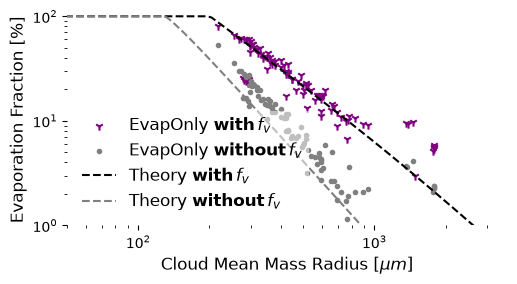

In [46]:
fig, ax = plt.subplots(1, 1)

x = ds["cloud_mass_radius_mean"]
y = ds["evaporation_fraction"]

x_no_ventilation = ds_no_ventilation["cloud_mass_radius_mean"]
y_no_ventilation = ds_no_ventilation["evaporation_fraction"]


for mp in ["condensation"]:
    style = microphysics_styles.get_style(mp)
    style["label"] += r" $\mathbf{with} \, f_v$"
    ax.scatter(
        x.sel(microphysics=mp),
        y.sel(microphysics=mp),
        **style,
    )
    style = microphysics_styles.get_style(mp, colortype="light")
    style["label"] += r" $\mathbf{without} \, f_v$"
    style["color"] = "grey"
    style["marker"] = "."
    ax.scatter(
        x_no_ventilation.sel(microphysics=mp),
        y_no_ventilation.sel(microphysics=mp),
        **style,
    )

# ax.plot(
#     x.transpose('microphysics', ...),
#     y.transpose('microphysics', ...),
#     color = 'black',
#     alpha = 0.1,
#     zorder = 1,
# )

ax.plot(
    ds["radius_bins"],
    1e2 * evaporation_fraction_ventilation,
    label=r"Theory $\mathbf{with} \, f_v$",
    color="black",
    linestyle="--",
)

ax.plot(
    ds["radius_bins"],
    1e2 * evaporation_fraction,
    label=r"Theory $\mathbf{without} \, f_v$",
    color="grey",
    linestyle="--",
)

ax.set_xlim(50, None)
ax.set_ylim(1, None)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(label_from_attrs(x))
ax.set_ylabel(label_from_attrs(y))
ax.legend(loc="lower left")
fig.tight_layout()

save_figure(fig=fig, filepath=fig_dir / f"FIG-8-theoretical-scatter-{x.name}-{y.name}-VENTILATION")

# Microphysics

### Differences between microphysics 

##### Fig. 9

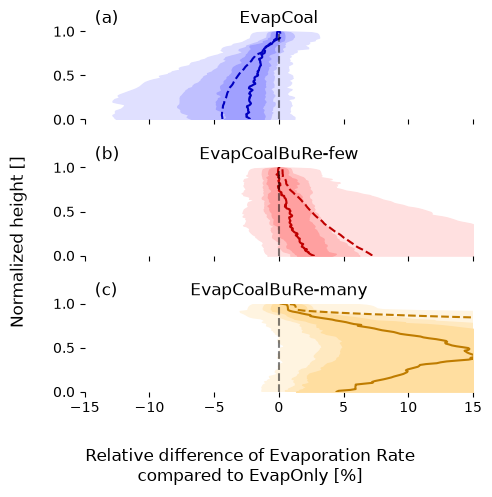

In [47]:
x_all = -ds_normalized["evaporation_rate_energy"]
x_refernce = x_all.sel(microphysics="condensation")

x_sem_all = ds_normalized_sem["evaporation_rate_energy"]
x_sem_refernce = x_sem_all.sel(microphysics="condensation")

attrs = x_all.attrs.copy()

# f = (A - B)/B

# df/dA = 1/B
# df/dB = -A/B**2

# df = sqrt((df/dA * dA)**2 + (df/dB * dB)**2)
# df = sqrt((1/B * dA)**2 + (-A/B**2 * dB)**2)

A = x_all
B = x_refernce
dA = x_sem_all
dB = x_sem_refernce

f = (A - B) / B
df = ((1 / B * dA) ** 2 + (-A / B**2 * dB) ** 2) ** 0.5

x = f * 100
x_sem = df * 100

x.attrs.update(
    long_name=f"Relative difference of {attrs['long_name']} compared to {microphysics_styles['condensation']['name']}",
    units=r"\%",
)

y = ds_normalized["normalized_gridbox_coord3"]


y_ticks = [0, 0.5, 1]

fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(5, 5), sharex=True, sharey=True)


plot_microphysics = [
    "collision_condensation",
    "coalbure_condensation_small",
    "coalbure_condensation_large",
]

for _ax, mp in zip(axs, plot_microphysics):

    _x = x.sel(microphysics=mp)
    _x_std = x_sem.sel(microphysics=mp)
    md_mean = _x.mean("cloud_id")
    md_std = propagate_mean_std(_x, _x_std, dim="cloud_id")

    style_full = microphysics_styles[mp].copy()

    _ax.set_title(microphysics_styles.get_setup(mp)["name"])

    _ax.plot(
        md_mean,
        y,
        color=style_full["dark_color"],
        linestyle="--",
        label="Mean",
        zorder=10,
    )
    _ax.plot(
        _x.median("cloud_id"),
        y,
        color=style_full["dark_color"],
        linestyle="-",
        label="Median",
        zorder=10,
    )

    _ax.fill_betweenx(
        y,
        _x.quantile(0.1, "cloud_id"),
        _x.quantile(0.9, "cloud_id"),
        zorder=1,
        color=adjust_lightness(style_full["light_color"], 1.5),
        label="10-90%",
    )
    _ax.fill_betweenx(
        y,
        _x.quantile(0.25, "cloud_id"),
        _x.quantile(0.75, "cloud_id"),
        zorder=2,
        color=adjust_lightness(style_full["light_color"], 1.4),
        label="25-75%",
    )
    _ax.fill_betweenx(
        y,
        _x.quantile(0.33, "cloud_id"),
        _x.quantile(0.66, "cloud_id"),
        zorder=3,
        color=adjust_lightness(style_full["light_color"], 1.3),
        label="33-66%",
    )


for _ax in axs:
    _ax.axvline(0, color="k", linestyle="--", alpha=0.5, zorder=10)
    _ax.set_xlim(-15, 15)
    _ax.set_ylim(0, 1)
    _ax.set_yticks(y_ticks)

fig.supxlabel(label_from_attrs(x, name_width=40))
fig.supylabel(label_from_attrs(y))
# fig.suptitle("Evaporation profiles | Difference to EvapOnly")
fig.tight_layout()

add_subplotlabel(axs=list(axs))

fig.tight_layout()

save_figure(fig, fig_dir / "FIG-9-evaporation_profiles_diff-percentile-normalized-NO-COMBINATION")

### Evaporation fraction and Mass radius mean

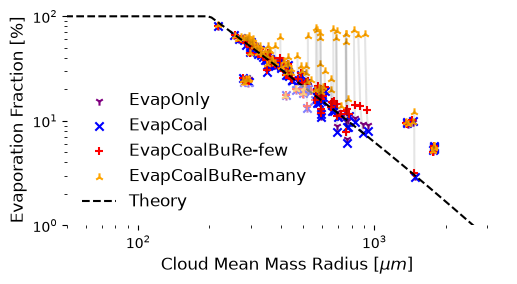

In [48]:
fig, ax = plt.subplots(1, 1)

x = ds["cloud_mass_radius_mean"]
y = ds["evaporation_fraction"]

# x_no_ventilation = ds_no_ventilation["cloud_mass_radius_mean"]
# y_no_ventilation = ds_no_ventilation["evaporation_fraction"]


for mp in microphysics_styles:
    style = microphysics_styles.get_style(mp)
    # style["label"] = None
    ax.scatter(
        x.sel(microphysics=mp),
        y.sel(microphysics=mp),
        **style,
    )

ax.plot(
    x.transpose("microphysics", ...),
    y.transpose("microphysics", ...),
    color="black",
    alpha=0.1,
    zorder=1,
)

ax.plot(
    ds["radius_bins"],
    1e2 * evaporation_fraction_ventilation,
    label=r"Theory",
    color="black",
    linestyle="--",
)

# ax.plot(
#     ds["radius_bins"],
#     1e2 * evaporation_fraction,
#     label=r"Theory $\mathbf{without} \, f_v$",
#     color="grey",
#     linestyle="--",
# )

ax.set_xlim(50, None)
ax.set_ylim(1, None)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(label_from_attrs(x))
ax.set_ylabel(label_from_attrs(y))
ax.legend(loc="lower left")
fig.tight_layout()

save_figure(fig=fig, filepath=fig_dir / f"theoretical-scatter-{x.name}-{y.name}-ALL")

### Column integrated evaporation and cloud base precipitation flux

##### Fig. 10

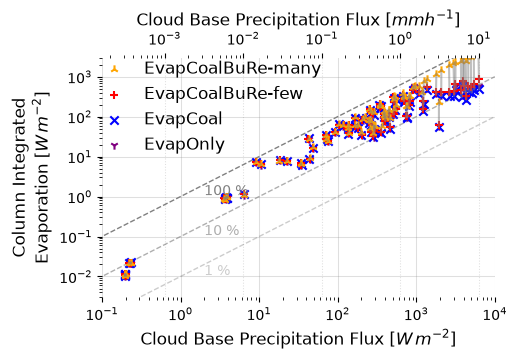

In [49]:
fig, ax = plt.subplots(1, 1, figsize=(small_fig_size[0], small_fig_size[1] * 1.25))
# ax_no_ventilation = plt.Axes = axs[1]


x = ds["inflow_energy"]
y = -ds["source_energy"]

# x_no_ventilation = ds_no_ventilation["inflow_precipitation"]
# y_no_ventilation = - ds_no_ventilation["source_precipitation"]


for mp in microphysics_styles:
    style = microphysics_styles.get_style(mp)
    ax.scatter(
        x.sel(microphysics=mp),
        y.sel(microphysics=mp),
        **style,
    )

# for _ax in axs:
#     _ax.set_xscale("log")
#     _ax.set_yscale("log")
#     _ax.set_xlabel(label_from_attrs(x))
#     _ax.set_ylabel(label_from_attrs(y))


ax.plot(
    x.transpose("microphysics", ...),
    y.transpose("microphysics", ...),
    color="grey",
    alpha=0.5,
)


ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(3e-3, 3e3)
ax.set_xlim(1e-1, 1e4)
xlim = np.array(ax.get_xlim())
ylim = np.array(ax.get_ylim())

lims = np.concatenate([xlim, ylim])

p_x_values = np.geomspace(lims.min(), lims.max(), 100)

values_label_size = 10

for p in [1, 0.1, 0.01]:
    style = dict(color="grey", alpha=p ** (1 / 5))
    lines = ax.plot(p_x_values, p * p_x_values, "--", linewidth=1, zorder=0, **style)
    line = lines[0]
    _x = 2e4
    _y = p * _x

    ax.annotate(
        f"{100 * p:.0f} %",
        xy=(_x, _y),
        xytext=(10, 10),
        textcoords="offset points",
        va="top",
        ha="left",
        size=values_label_size,
        **style,
    )
    _x = 2e0
    _y = p * _x

    ax.annotate(
        f"{100 * p:.0f} %",
        xy=(_x, _y),
        xytext=(0, 0),
        textcoords="offset points",
        va="top",
        ha="left",
        size=values_label_size,
        **style,
    )

x_ticks = xr.DataArray(ax.get_xticks(), attrs=x.attrs.copy())
new_x_ticks: xr.DataArray = conversions.EvaporationUnits(data=x_ticks, input_type="energy").convert_to(
    "precipitation"
)

factor = new_x_ticks / x_ticks

assert (
    np.abs(factor.std() / factor.mean()) < 1e-6
), f"Conversion factor is not constant: std={factor.std}, mean={factor.mean}"
factor = factor.mean().data

# add a second xaxis
ax2 = ax.twiny()
ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlim(factor * xlim)  # Sync the x-limits
ax2.set_ylim(ylim)  # Sync the x-limits

ax2.set_xlabel(label_from_attrs(da=new_x_ticks))
ax.grid(color="grey", alpha=0.25, linewidth=0.75)
ax2.grid(color="grey", alpha=0.25, linewidth=0.75, linestyle=":")

ax.set_xlabel(label_from_attrs(x))
ax.set_ylabel(label_from_attrs(y, name_width=20))

fig.tight_layout()

# flip legend
handles, labels = ax.get_legend_handles_labels()
order = [3, 2, 1, 0]
legend = ax.legend(
    [handles[idx] for idx in order],
    [labels[idx] for idx in order],
    loc="upper left",
    bbox_to_anchor=(-0.05, 1.05),
    frameon=False,
    facecolor=[0, 0, 0, 0],
)

fig.tight_layout()

save_figure(fig=fig, filepath=fig_dir / f"FIG-10-{x.name}-{y.name}-scatter-ALL")

# Appendix

### Scatter plot of EV and CIE

##### Fig. A1

151.98 $\pm$ 174.54 $W \, m^{-2}$ 28.48 $\pm$ 18.36 $\%$
139.23 $\pm$ 153.08 $W \, m^{-2}$ 27.51 $\pm$ 17.65 $\%$
167.43 $\pm$ 205.70 $W \, m^{-2}$ 28.95 $\pm$ 17.88 $\%$
490.08 $\pm$ 936.44 $W \, m^{-2}$ 40.40 $\pm$ 21.10 $\%$


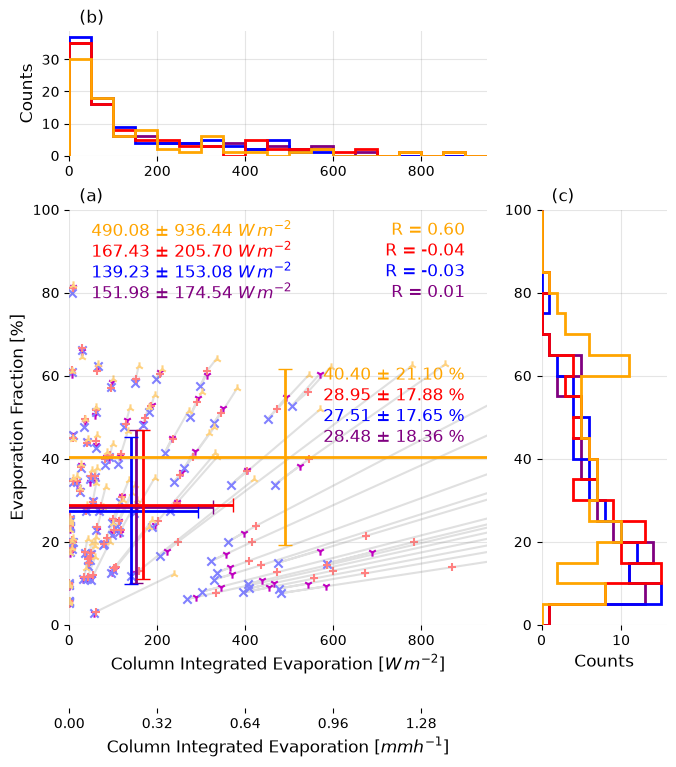

In [50]:
fig, axs = plt.subplots(
    2, 2, figsize=large_square_fig_size, width_ratios=[1, 0.3], height_ratios=[0.3, 1]
)

ax_empty = axs[0, 1]
ax_empty.axis("off")
ax_x_hist = axs[0, 0]
ax_y_hist = axs[1, 1]
ax_scatter = axs[1, 0]

ax_x_hist.sharex(ax_scatter)
ax_y_hist.sharey(ax_scatter)

x = -ds["source_energy"]
y = ds["evaporation_fraction"]
c = ds["cloud_liquid_water_content"]

x_median = x.median("cloud_id")
y_median = y.median("cloud_id")

x_bins = np.arange(0, 1000, 50)
y_bins = np.arange(0, 101, 5)

ax_scatter.set_xlim(x_bins[0], x_bins[-1])
ax_scatter.set_ylim(y_bins[0], y_bins[-1])

for i, mp in enumerate(microphysics_styles):

    style = microphysics_styles.get_style(mp)

    data_dict, plot_dict = scatter_and_errorbar(
        ax=ax_scatter,
        x_var=x.name,
        y_var=y.name,
        ds=ds,
        ds_sem=ds_sem,
        microphysics=mp,
        x_multiply=-1,
        y_multiply=1,
        plot_patch=False,
        plot_annotations=True,
        patch_width=2.5,
        scatter_kwargs=dict(
            color=adjust_lightness(style["color"], 1.5),
            marker=style["marker"],
            alpha=1,
        ),
        error_kwargs=dict(
            fmt="",
            label="mean ± SEM",
            color=style["color"],
            capsize=5,
            linewidth=2,
        ),
        annotation_kwargs=dict(
            color=style["color"],
        ),
    )

    # add correlation annotation
    x_var = x.name
    y_var = y.name
    correlation = xr.corr(-ds[x_var], ds[y_var], dim="cloud_id")

    ax_scatter.annotate(
        f" R = {correlation.sel(microphysics=mp).data:.2f}",
        xy=(900, 80 + 5 * i),
        color=style["color"],
        xycoords="data",
        ha="right",
        va="center",
    )

    ax_x_hist.hist(
        x.sel(microphysics=mp),
        bins=x_bins,
        histtype="step",
        color=style["color"],
        lw=2,
    )
    ax_y_hist.hist(
        y.sel(microphysics=mp),
        bins=y_bins,
        histtype="step",
        color=style["color"],
        lw=2,
        orientation="horizontal",
    )

    x_annotation = plot_dict["x_annotation"]
    x_annotation.set(
        x=50,
        y=80 + 5 * i,
        ha="left",
        va="center",
    )

    y_annotation = plot_dict["y_annotation"]
    y_annotation.set(
        x=900,
        y=45 + 5 * i,
        rotation=0,
        ha="right",
        va="center",
    )


ax_scatter.plot(
    x,
    y,
    color=adjust_lightness("grey", 1.75),
    zorder=0,
)

ax_scatter.set_xlabel(label_from_attrs(x))
ax_scatter.set_ylabel(label_from_attrs(y))

ax_x_hist.set_ylabel("Counts")
ax_y_hist.set_xlabel("Counts")


# add additional x axis with converted units

x_ticks = xr.DataArray(ax_scatter.get_xticks(), attrs=x.attrs.copy())
new_x_ticks: xr.DataArray = conversions.EvaporationUnits(data=x_ticks, input_type="energy").convert_to(
    "precipitation"
)
new_ticks_func = lambda _: [f"{round(new_x, 2):.2f}" for x, new_x in zip(x_ticks, new_x_ticks.data)]
add_additional_axis(
    ax=ax_scatter,
    new_ticks_func=new_ticks_func,
    label=label_from_attrs(da=new_x_ticks),
    position="bottom",
    offset_position=["axes", -0.2],
)
ax_scatter.set_xlabel(label_from_attrs(da=x))

for _ax in axs.flatten():
    _ax.grid(linestyle="-", alpha=0.2, color="grey")

add_subplotlabel([ax_scatter, ax_x_hist, ax_y_hist], location="title")

# fig.tight_layout()
save_figure(
    fig=fig, filepath=appendix_fig_dir / f"FIG-A1-{x.name}-{y.name}-scattered-histograms-LINEAR-ALL"
)

### Relative differnces

##### Fig. A2

/tmp/ipykernel_1096126/1802330621.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axs[i, 1].set_yticklabels(axs[i, 0].get_yticklabels())
/tmp/ipykernel_1096126/1802330621.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axs[i, 1].set_yticklabels(axs[i, 0].get_yticklabels())


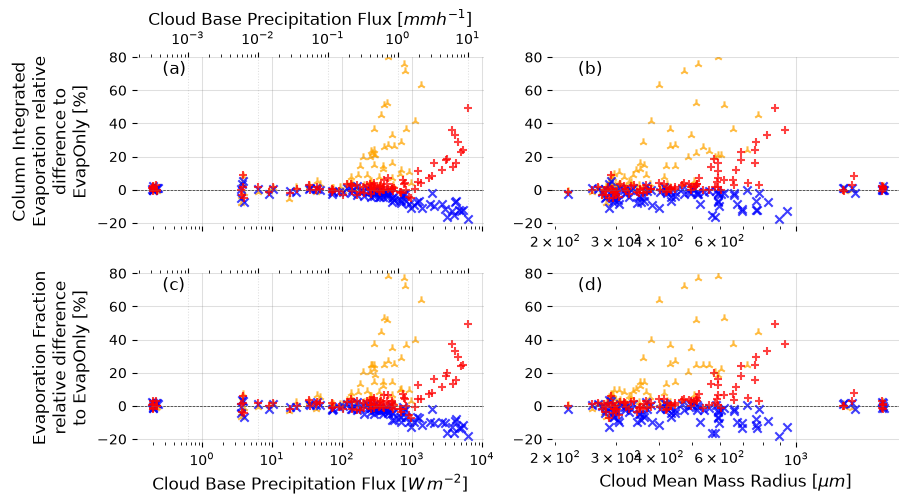

In [51]:
def plot_relative_differences(
    ax: plt.Axes,
    y_var_name: str,
    x_var_name: str,
    ds: xr.Dataset,
    ds_sem: xr.Dataset,
    microphysics_list: list = [
        "collision_condensation",
        "coalbure_condensation_small",
        "coalbure_condensation_large",
    ],
):

    y = ds[x_var_name]

    x_all = ds[y_var_name]
    x_refernce = x_all.sel(microphysics="condensation")

    x_sem_all = ds_sem[y_var_name]
    x_sem_refernce = x_sem_all.sel(microphysics="condensation")

    attrs = x_all.attrs.copy()

    # f = (A - B)/B

    # df/dA = 1/B
    # df/dB = -A/B**2

    # df = sqrt((df/dA * dA)**2 + (df/dB * dB)**2)
    # df = sqrt((1/B * dA)**2 + (-A/B**2 * dB)**2)

    A = x_all
    B = x_refernce
    dA = x_sem_all
    dB = x_sem_refernce

    f = (A - B) / B
    df = ((1 / B * dA) ** 2 + (-A / B**2 * dB) ** 2) ** 0.5

    x = f * 100
    x_sem = df * 100

    x.attrs.update(
        long_name=f"{attrs['long_name']} relative difference to {microphysics_styles['condensation']['name']}",
        units=r"\%",
    )

    x, y = y, x
    x = x.sel(microphysics=microphysics_list)
    y = y.sel(microphysics=microphysics_list)

    # x_no_ventilation = ds_no_ventilation["inflow_precipitation"]
    # y_no_ventilation = - ds_no_ventilation["source_precipitation"]

    for mp in microphysics_list:
        style = microphysics_styles.get_style(mp).copy()
        ax.scatter(
            x.sel(microphysics=mp),
            y.sel(microphysics=mp),
            alpha=0.75,
            **style,
        )

    # for _ax in axs:
    #     _ax.set_xscale("log")
    #     _ax.set_yscale("log")
    #     _ax.set_xlabel(label_from_attrs(x))
    #     _ax.set_ylabel(label_from_attrs(y))

    # ax.plot(
    #     x.transpose("microphysics", ...),
    #     y.transpose("microphysics", ...),
    #     color="grey",
    #     alpha=0.1,
    # )

    ax.axhline(0, color="black", linestyle="--", linewidth=0.5, zorder=0)
    # ax.set_yscale('symlog', linthresh = 1e-6, linscale = 0.2)
    # lims = np.array([1e-6, 2.5e1])
    # ax.set_ylim(lims.min(), lims.max())
    # ax.set_xlim(1e-4, lims.max())

    ax.set_xlabel(label_from_attrs(x))
    ax.set_ylabel(label_from_attrs(y, name_width=20))
    # ax.legend(loc = "upper left")

    return ax


# ax_no_ventilation = plt.Axes = axs[1]

variable_combinations = [
    ("inflow_energy", "source_energy"),
    ("cloud_mass_radius_mean", "source_energy"),
    # ("mean_evaporation_height", "source_precipitation"),
    ("inflow_energy", "evaporation_fraction"),
    ("cloud_mass_radius_mean", "evaporation_fraction"),
    # ('mean_evaporation_height', "evaporation_fraction"),
]


fig, axs = plt.subplots(nrows=2, ncols=2, figsize=large_fig_size * 1.2)

# axs = axs.flatten(order="C")

axs2 = []

for _ax, (_x, _y) in zip(
    axs.flatten(),
    variable_combinations,
):

    x = ds[_x]
    y = ds[_y]

    _ax = plot_relative_differences(
        ax=_ax,
        x_var_name=_x,
        y_var_name=_y,
        ds=ds,
        ds_sem=ds_sem,
        microphysics_list=[
            "coalbure_condensation_large",
            "collision_condensation",
            "coalbure_condensation_small",
        ],
    )
    _ax.set_xscale("log")
    _ax.set_yscale("linear")
    _ax.set_ylim(-22, 80)
    _ax.set_xlabel(label_from_attrs(da=x))

    # add additional x axis with converted units
    _ax.grid(color="grey", alpha=0.25, linewidth=0.75)

    if _x == "inflow_energy":
        x_ticks = xr.DataArray(_ax.get_xticks(), attrs=x.attrs.copy())
        new_x_ticks: xr.DataArray = conversions.EvaporationUnits(
            data=x_ticks, input_type="energy"
        ).convert_to("precipitation")

        factor = new_x_ticks / x_ticks

        assert (
            np.abs(factor.std() / factor.mean()) < 1e-6
        ), f"Conversion factor is not constant: std={factor.std}, mean={factor.mean}"
        factor = factor.mean().data

        # add a second xaxis
        _xlim = np.array(_ax.get_xlim())
        _ax2 = _ax.twiny()
        _ax2.set_xscale("log")
        _ax2.set_yscale("linear")
        _ax2.set_xlim(factor * _xlim)  # Sync the x-limits
        _ax2.set_xlabel(label_from_attrs(da=new_x_ticks))

        _ax2.grid(color="grey", alpha=0.25, linewidth=0.75, linestyle=":")

        axs2.append(_ax2)

for _ax in axs[0, :]:
    _ax.set_xlabel("")
    _ax.set_xticklabels([])
for i in range(2):
    axs[i, 1].set_ylabel("")
    axs[i, 1].set_yticklabels(axs[i, 0].get_yticklabels())

add_subplotlabel(axs=axs.flatten(), location="upper left")

axs2[1].set_xlabel("")
axs2[1].set_xticklabels([])

fig.tight_layout()

save_figure(
    fig=fig, filepath=appendix_fig_dir / f"FIG-A2-microphysics-relative-differences-COMBINED-PLOTS-all"
)

### All correlations as a mosaic

##### Fig. A3

In [52]:
correlation_vars = (
    "cloud_mass_radius_mean",
    "cloud_liquid_water_content",
    "inflow_precipitation",
    "relative_humidity_mean",
    "cloud_base_height",
)

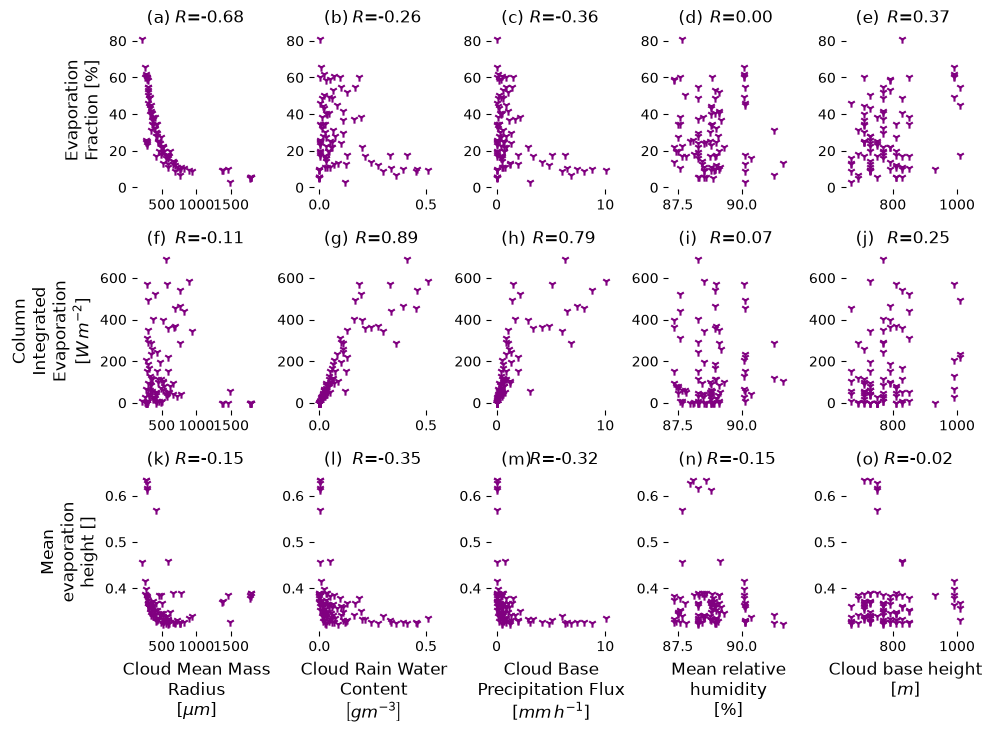

In [53]:
fig, axs = plt.subplots(nrows=3, ncols=len(correlation_vars), figsize=(2 * len(correlation_vars), 7.5))

axs_ef: Tuple[plt.Axes, plt.Axes, plt.Axes] = axs[0]
axs_ef[1].sharey(axs_ef[0])
axs_ef[2].sharey(axs_ef[0])

axs_cie: Tuple[plt.Axes, plt.Axes, plt.Axes] = axs[1]
axs_cie[1].sharey(axs_cie[0])
axs_cie[2].sharey(axs_cie[1])

axs_meh: Tuple[plt.Axes, plt.Axes, plt.Axes] = axs[2]
axs_meh[1].sharey(axs_meh[0])
axs_meh[2].sharey(axs_meh[1])

# for the evaporation fraction
for i, var in enumerate(correlation_vars):
    y = ds["evaporation_fraction"].sel(microphysics="condensation")
    x = ds[var].sel(microphysics="condensation")
    correlation = ds_correlations_EF[var].sel(microphysics="condensation")
    correlation_log = ds_correlations_log_EF[var].sel(microphysics="condensation")
    axs_ef[i].set_title("     " + r"$R$" + f"={correlation.data:.2f}")
    axs_ef[i].scatter(
        x,
        y,
        **microphysics_styles.get_style("condensation"),
    )
    axs_ef[i].set_xlabel(label_from_attrs(x, name_width=20, linebreak=True))

axs_ef[0].set_ylabel(label_from_attrs(y, name_width=15))

# for the column integrate evaporation
for i, var in enumerate(correlation_vars):
    y = -ds["source_energy"].sel(microphysics="condensation")
    x = ds[var].sel(microphysics="condensation")
    correlation = ds_correlations_CIE[var].sel(microphysics="condensation")
    correlation_log = ds_correlations_log_CIE[var].sel(microphysics="condensation")
    axs_cie[i].set_title("     " + r"$R$" + f"={correlation.data:.2f}")
    axs_cie[i].scatter(
        x,
        y,
        **microphysics_styles.get_style("condensation"),
    )
    axs_cie[i].set_xlabel(label_from_attrs(x, name_width=20, linebreak=True))

axs_cie[0].set_ylabel(label_from_attrs(y, name_width=15, linebreak=True))

# for the mean evaporation height
for i, var in enumerate(correlation_vars):
    y = ds["mean_evaporation_height"].sel(microphysics="condensation")
    x = ds[var].sel(microphysics="condensation")
    correlation = ds_correlations_MEH[var].sel(microphysics="condensation")
    correlation_log = ds_correlations_log_MEH[var].sel(microphysics="condensation")
    axs_meh[i].set_title("     " + r"$R$" + f"={correlation.data:.2f}")
    axs_meh[i].scatter(
        x,
        y,
        **microphysics_styles.get_style("condensation"),
    )
    axs_meh[i].set_xlabel(label_from_attrs(x, name_width=20, linebreak=True))

axs_meh[0].set_ylabel(label_from_attrs(y, name_width=15))


for _axs in axs[:, 1:]:
    for _ax in _axs.flatten():
        _ax.set_ylabel("")
for _axs in [axs_ef, axs_cie]:
    for _ax in _axs.flatten():
        _ax.set_xlabel("")
add_subplotlabel(axs=axs.flatten(), location="title")


fig.tight_layout()
save_figure(fig, appendix_fig_dir / "FIG-A3-all-correlations")